# P1 · PyTorch Fundamentals for Transformers

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## Chapter index

**Section 1 · Understand tensors**

- P1.1 · What a tensor contains — P1-pytorch-tensors.ipynb
- P1.2 · Read tensor axes — P1-pytorch-axes.ipynb
- P1.3 · Select the values you mean — P1-pytorch-indexing.ipynb
- P1.4 · Assemble sequences and batches — P1-pytorch-batches.ipynb
- P1.5 · Reshape without losing meaning — P1-pytorch-reshape.ipynb

**Section 2 · Calculate and build**

- P1.6 · Elementwise operations and broadcasting — P1-pytorch-broadcasting.ipynb
- P1.7 · Reduce along the right axis — P1-pytorch-reductions.ipynb
- P1.8 · Matrix multiplication and linear layers — P1-pytorch-matmul.ipynb
- P1.9 · Embeddings and positions — P1-pytorch-embeddings.ipynb
- P1.10 · Modules, parameters, and model state — P1-pytorch-modules.ipynb

**Section 3 · Assemble the model**

- P1.11 · Assemble attention tensors — P1-pytorch-attention.ipynb
- P1.12 · Feed-forward blocks and residual paths — P1-pytorch-blocks.ipynb
- P1.13 · Predictions, targets, and loss — P1-pytorch-loss.ipynb
- P1.14 · Autograd follows the computation — P1-pytorch-autograd.ipynb

**Section 4 · Learn and generate**

- P1.15 · Perform one training step — P1-pytorch-step.ipynb
- P1.16 · Evaluation and repeatable experiments — P1-pytorch-modes.ipynb
- P1.17 · Generate one token at a time — P1-pytorch-generation.ipynb
- P1.18 · Read, run, save, and restore — P1-pytorch-capstone.ipynb

# Section 1 · Understand tensors

- P1.1 · What a tensor contains
- P1.2 · Read tensor axes
- P1.3 · Select the values you mean
- P1.4 · Assemble sequences and batches
- P1.5 · Reshape without losing meaning

## P1.1 · What a tensor contains

Inspect values, shape, dtype and device together: each is part of the next operation’s input contract.

**Prerequisites:** Basic variables, loops and functions.

**Predict:** Does converting IDs to float create embeddings?

**Mental model:** The same printed numbers can participate in different operations. An integer ID names an entry, while a floating-point feature is a value a layer calculates with.

<a data-compat-cell="p1-tensors"></a>

### P1.1.1 · Understand the need

The same printed numbers can participate in different operations. An integer ID names an entry, while a floating-point feature is a value a layer calculates with.

A tensor carries a shape, a data type and a device as well as its values. A valid operation must satisfy all those contracts.

A Boolean tensor records a yes-or-no result at each position. Such comparisons become masks inside attention and evaluation code.

Converting integer IDs to floating point changes their representation, not their meaning. Casting IDs is not an embedding lookup.

Begin every unfamiliar tensor operation by inspecting its input. The resulting error message is easier to interpret when these properties are visible.

### P1.1.2 · Follow the values

Create the integer sequence two, zero and one. It has one axis containing three entries on the CPU.

Convert those values to floating point. The values remain two, zero and one; the dtype changes to the selected floating-point format.

Compare the IDs with zero. The comparison returns true, false and true, preserving the original shape.

Inspect shape, dtype, device and the total element count together. Shape describes arrangement, while element count is the product of axis lengths.

Extract one scalar with item and the full sequence with tolist. These return ordinary Python values for inspection outside tensor calculations.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
ids = torch.tensor([2, 0, 1], dtype=torch.long)
show("Integer IDs", ids)
features = ids.to(torch.float64 if change else torch.float32)
show("Floating-point values", features)
show("Boolean comparison", ids > 0)
show("Properties", {"shape": list(ids.shape), "dtype": str(ids.dtype), "device": str(ids.device), "elements": ids.numel()})
show("Tensor to Python", {"one item": ids[0].item(), "all items": ids.tolist()})

Integer IDs: [2, 0, 1]
  shape [3] · torch.int64 · cpu
Floating-point values: [2.0, 0.0, 1.0]
  shape [3] · torch.float32 · cpu
Boolean comparison: [true, false, true]
  shape [3] · torch.bool · cpu
Properties: {"shape": [3], "dtype": "torch.int64", "device": "cpu", "elements": 3}
Tensor to Python: {"one item": 2, "all items": [2, 0, 1]}


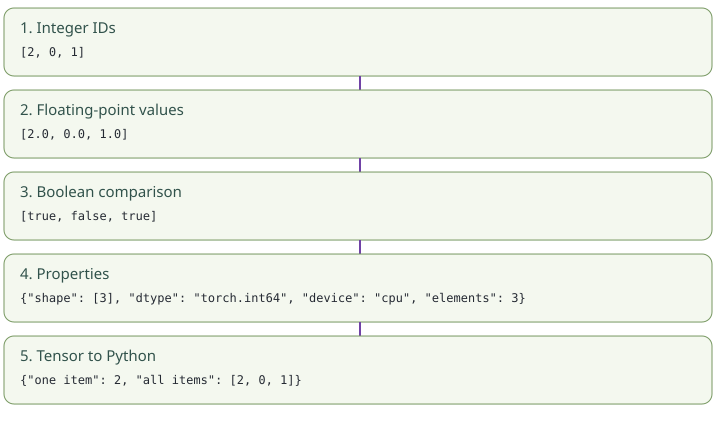

In [4]:
draw_trace()

### P1.1.3 · Read and run the code

Torch tensor constructs values from Python data. Specify long for the ID examples so an implicit dtype choice cannot obscure their role.

The to method can change a tensor's data type or device. Use the returned tensor rather than assuming every conversion mutates the original object.

A comparison operates element by element and produces a Boolean tensor. Multiple truth values cannot be used as one Python condition without an explicit reduction.

Shape is an attribute; numel is a method and needs parentheses. Item also needs parentheses and requires exactly one element.

Create zeros, ones, an ordered range, or normal random samples with the matching tensor constructors. Inspect their dtype and device too, especially when creating a new tensor beside an existing one.

### Change one thing

**Use float64 instead of float32**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
ids = torch.tensor([2, 0, 1], dtype=torch.long)
show("Integer IDs", ids)
features = ids.to(torch.float64 if change else torch.float32)
show("Floating-point values", features)
show("Boolean comparison", ids > 0)
show("Properties", {"shape": list(ids.shape), "dtype": str(ids.dtype), "device": str(ids.device), "elements": ids.numel()})
show("Tensor to Python", {"one item": ids[0].item(), "all items": ids.tolist()})

Integer IDs: [2, 0, 1]
  shape [3] · torch.int64 · cpu
Floating-point values: [2.0, 0.0, 1.0]
  shape [3] · torch.float64 · cpu
Boolean comparison: [true, false, true]
  shape [3] · torch.bool · cpu
Properties: {"shape": [3], "dtype": "torch.int64", "device": "cpu", "elements": 3}
Tensor to Python: {"one item": 2, "all items": [2, 0, 1]}


### A useful distinction

Casting an ID to float does not turn it into a learned embedding.

### ✋ Your turn

Create a long tensor [1,2,3] and put its element count in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'Casting an ID to float does not turn it into a learned embedding.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
answer = torch.tensor([1, 2, 3], dtype=torch.long).numel()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'Casting an ID to float does not turn it into a learned embedding.'
    print("✓ right:", answer)

✓ right: 3


### P1.1.4 · Find it in the model

Token inputs arrive as integer tensors. Embedding tables and intermediate model features use floating-point tensors, while causal permissions can use Boolean masks.

Position indices must be created on the same device as the input when the embedding lookup runs there. The model passes the input's device to arange.

Training gradients apply to appropriate floating-point parameters, not to the integer labels naming characters. The gradient chapter will make that distinction concrete.

CPU execution is enough for these notebooks. Device transfers become important for larger models, but they do not change what the axes mean.

Next, read those axes from scalars to the four-dimensional tensors used by attention.

```python
positions = torch.arange(T, device=idx.device)
x = self.tok_emb(idx) + self.pos_emb(positions)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does converting IDs to float create embeddings?

<details><summary>Check your explanation</summary>

No; lookup uses a separate learned table. Casting an ID to float does not turn it into a learned embedding.

</details>

## P1.2 · Read tensor axes

A shape gives axis lengths; axis names explain what those lengths mean.

**Prerequisites:** What a tensor contains

**Predict:** How many axes remain after selecting x[0,1] from [2,2,3,2]?

**Mental model:** Four-dimensional attention tensors are easier to read as four questions. Which batch example, which head, which token, and which feature are you selecting?

<a id="pytorch-shapes"></a>

<a data-compat-cell="p1-shapes-indexing-and-slicing"></a>

### P1.2.1 · Understand the need

Four-dimensional attention tensors are easier to read as four questions. Which batch example, which head, which token, and which feature are you selecting?

The shape gives how many answers each question permits. It does not name the questions, so keep axis labels beside the numbers.

Select one axis at a time. Each integer selection removes that axis and leaves the remaining questions to be answered.

A scalar has no remaining axes, although it still holds one value. Zero axes do not mean zero elements.

Rank here means the number of tensor axes. This usage is different from the mathematical rank of a matrix.

### P1.2.2 · Follow the values

Arrange the integers zero through twenty-three into two batches, two heads, three tokens and two features. Every coordinate has an identifiable value.

Select the first batch. Twelve values remain, organized as two heads with three tokens of two features each.

Select head one inside that batch. Its three token vectors contain six values: six through eleven.

Select token two from that head. Its feature vector contains ten and eleven.

Select feature zero and obtain the scalar ten. Switch batches and repeat the coordinates: the selected value becomes twenty-two while the interpretation stays the same.

In [8]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 2, 3, 2)
show("[batch, head, token, feature]", x)
b = 1 if change else 0
show("Select a batch: [head, token, feature]", x[b])
show("Select a head: [token, feature]", x[b, 1])
show("Select a token: [feature]", x[b, 1, 2])
show("Select a feature: scalar", x[b, 1, 2, 0])

[batch, head, token, feature]: [[[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]], [[[12, 13], [14, 15], [16, 17]], [[18, 19], [20, 21], [22, 23]]]]
  shape [2, 2, 3, 2] · torch.int64 · cpu
Select a batch: [head, token, feature]: [[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]]
  shape [2, 3, 2] · torch.int64 · cpu
Select a head: [token, feature]: [[6, 7], [8, 9], [10, 11]]
  shape [3, 2] · torch.int64 · cpu
Select a token: [feature]: [10, 11]
  shape [2] · torch.int64 · cpu
Select a feature: scalar: 10
  shape [] · torch.int64 · cpu


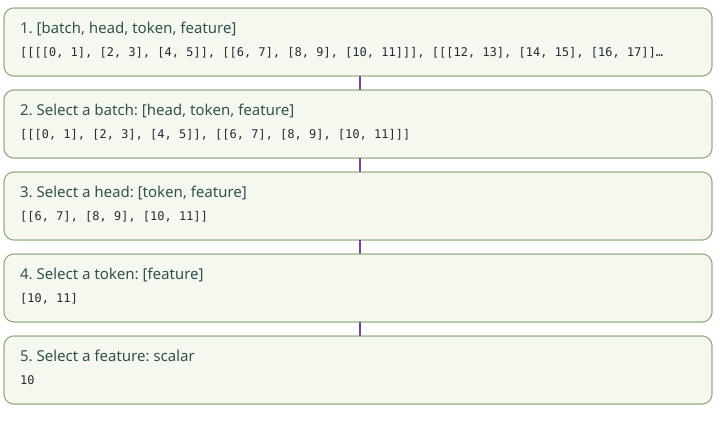

In [9]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

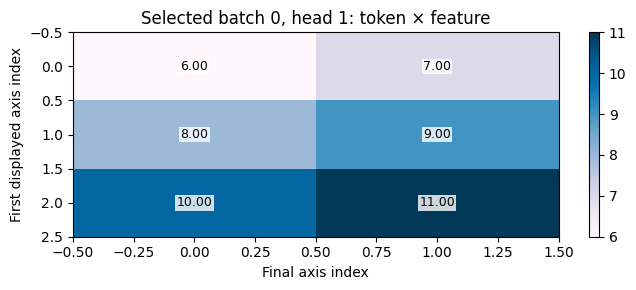

In [10]:
image = (x[0,1].float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Selected batch 0, head 1: token × feature'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.2.3 · Read and run the code

Arange creates unique values so rearrangement mistakes stay visible. Reshape arranges them in the requested four-axis layout.

Unpack x dot shape into batch, heads, tokens and features when you need named sizes. Check that those names match the operation's actual convention.

An integer index removes an axis. A length-one slice keeps an axis, which can matter when later broadcasting expects it.

Negative axis numbers count from the end. The final feature axis is axis minus one, and the token axis is minus two in this layout.

Use shape assertions at important boundaries. They document the interface, but also inspect coordinates when an incorrect permutation could preserve the same shape.

### Change one thing

**Select batch 1 instead of batch 0**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [11]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 2, 3, 2)
show("[batch, head, token, feature]", x)
b = 1 if change else 0
show("Select a batch: [head, token, feature]", x[b])
show("Select a head: [token, feature]", x[b, 1])
show("Select a token: [feature]", x[b, 1, 2])
show("Select a feature: scalar", x[b, 1, 2, 0])

[batch, head, token, feature]: [[[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]], [[[12, 13], [14, 15], [16, 17]], [[18, 19], [20, 21], [22, 23]]]]
  shape [2, 2, 3, 2] · torch.int64 · cpu
Select a batch: [head, token, feature]: [[[12, 13], [14, 15], [16, 17]], [[18, 19], [20, 21], [22, 23]]]
  shape [2, 3, 2] · torch.int64 · cpu
Select a head: [token, feature]: [[18, 19], [20, 21], [22, 23]]
  shape [3, 2] · torch.int64 · cpu
Select a token: [feature]: [22, 23]
  shape [2] · torch.int64 · cpu
Select a feature: scalar: 22
  shape [] · torch.int64 · cpu


### A useful distinction

A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.

### ✋ Your turn

For x shaped [2,2,3,2], put tuple(x[0,1].shape) in answer.

In [12]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (3,2), 'A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [13]:
#@title Show a solution { display-mode: "form" }
x = torch.arange(24).reshape(2,2,3,2)
answer = tuple(x[0,1].shape)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (3,2), 'A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.'
    print("✓ right:", answer)

✓ right: (3, 2)


### P1.2.4 · Find it in the model

Our tiny transformer uses two heads, each with fourteen features. A batch with four token positions has query shape batch by two by four by fourteen.

Attention scores replace the final feature axis with a key-position axis. Their last two axes describe query positions and key positions.

Phyll uses more heads and features, but these axis meanings transfer. Its temporary fused QKV representation also introduces a fifth axis selecting query, key or value.

Bigger tensors do not require a different mental model. Select a small slice and preserve the axis labels when inspecting it.

Next, compare indexing operations that keep an axis with operations that remove it.

```python
B, T, C = x.shape
q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** How many axes remain after selecting x[0,1] from [2,2,3,2]?

<details><summary>Check your explanation</summary>

2. A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.

</details>

## P1.3 · Select the values you mean

Integer indexing removes an axis; slicing preserves it. Select targets without confusing their IDs with their scores.

**Prerequisites:** Read tensor axes

**Predict:** Which expression preserves a one-position time axis?

**Mental model:** Generation needs the prediction at the latest position, while training uses predictions at many positions. Selecting the right time axis is part of implementing that difference.

### P1.3.1 · Understand the need

Generation needs the prediction at the latest position, while training uses predictions at many positions. Selecting the right time axis is part of implementing that difference.

Two expressions can select equal values but return different shapes. An integer time index removes the axis; a one-position slice retains it.

Boolean indexing answers another question: which entries satisfy a condition? A mask over every axis collects selected entries into a single sequence.

Target IDs identify which candidate score to inspect. Gather selects those scores using an index tensor whose axes must match the operation.

Predict both values and shape before running an indexing expression. Either can reveal an incorrect assumption.

### P1.3.2 · Follow the values

Start with two examples, three time positions and four features. Unique integers identify every original coordinate.

Select the last time position with an integer index. Each example now has one vector of four features, with no time axis left.

Select the same position with a slice. The values match, but the shape still includes a time axis of length one.

Select even entries using a full Boolean mask. The result is a flat collection of the entries that passed the test.

Finally, gather candidate zero for the first score vector and candidate two for the second. The selected scores are two and two, held in a two-by-one tensor.

In [14]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 3, 4)
show("[batch, time, features]", x)
position = -2 if change else -1
show("Integer time index", x[:, position, :])
show("Length-one time slice", x[:, position:position+1 if position != -1 else None, :])
show("Boolean selection of even entries", x[x % 2 == 0])
scores = torch.tensor([[2., 1., 0.], [0., 4., 2.]])
targets = torch.tensor([[0], [2]])
show("One selected score per example", scores.gather(1, targets))

[batch, time, features]: [[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]], [[12, 13, 14, 15], [16, 17, 18, 19], [20, 21, 22, 23]]]
  shape [2, 3, 4] · torch.int64 · cpu
Integer time index: [[8, 9, 10, 11], [20, 21, 22, 23]]
  shape [2, 4] · torch.int64 · cpu
Length-one time slice: [[[8, 9, 10, 11]], [[20, 21, 22, 23]]]
  shape [2, 1, 4] · torch.int64 · cpu
Boolean selection of even entries: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
  shape [12] · torch.int64 · cpu
One selected score per example: [[2.0], [2.0]]
  shape [2, 1] · torch.float32 · cpu


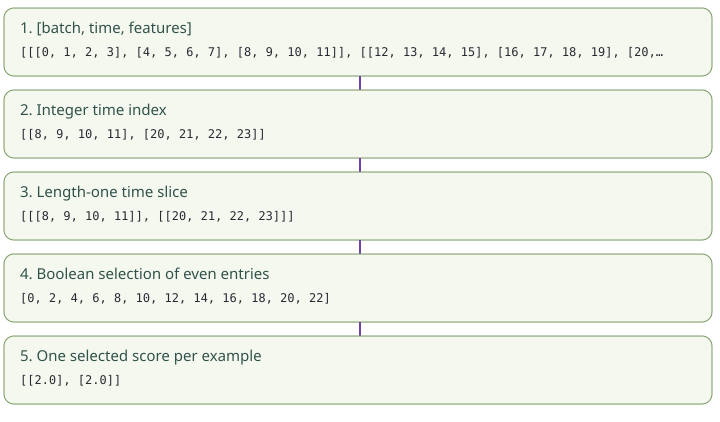

In [15]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

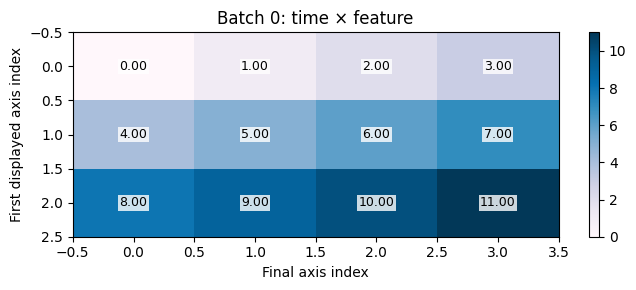

In [16]:
image = (x[0].float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Batch 0: time × feature'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.3.3 · Read and run the code

A colon preserves all entries of an axis. The middle integer in the first selection removes only the time axis, leaving batch and feature axes.

The stop boundary of a slice remains exclusive. A slice ending at the sequence boundary can use None to include the last available position.

A tensor comparison produces a Boolean mask. Use tensor Boolean operations and explicit reductions instead of Python and over multiple tensor values.

Gather receives the selection axis and an integer index tensor. The index tensor retains the batch axis and adds a singleton selection axis here.

Item is suitable only after selecting one element. Converting a whole batch of results to a single Python scalar is a different and usually invalid request.

### Change one thing

**Select the previous time position**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [17]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 3, 4)
show("[batch, time, features]", x)
position = -2 if change else -1
show("Integer time index", x[:, position, :])
show("Length-one time slice", x[:, position:position+1 if position != -1 else None, :])
show("Boolean selection of even entries", x[x % 2 == 0])
scores = torch.tensor([[2., 1., 0.], [0., 4., 2.]])
targets = torch.tensor([[0], [2]])
show("One selected score per example", scores.gather(1, targets))

[batch, time, features]: [[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]], [[12, 13, 14, 15], [16, 17, 18, 19], [20, 21, 22, 23]]]
  shape [2, 3, 4] · torch.int64 · cpu
Integer time index: [[4, 5, 6, 7], [16, 17, 18, 19]]
  shape [2, 4] · torch.int64 · cpu
Length-one time slice: [[[4, 5, 6, 7]], [[16, 17, 18, 19]]]
  shape [2, 1, 4] · torch.int64 · cpu
Boolean selection of even entries: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
  shape [12] · torch.int64 · cpu
One selected score per example: [[2.0], [2.0]]
  shape [2, 1] · torch.float32 · cpu


### A useful distinction

The same selected values can have different shapes, which changes later broadcasting behavior.

### ✋ Your turn

Keep the last time position of x with shape [2,3,4], preserving all three axes; put its shape in answer.

In [18]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (2,1,4), 'The same selected values can have different shapes, which changes later broadcasting behavior.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [19]:
#@title Show a solution { display-mode: "form" }
x = torch.arange(24).reshape(2,3,4)
answer = tuple(x[:, -1:, :].shape)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (2,1,4), 'The same selected values can have different shapes, which changes later broadcasting behavior.'
    print("✓ right:", answer)

✓ right: (2, 1, 4)


### P1.3.4 · Find it in the model

The model returns logits for every input position. Generation selects the final position before converting its candidate scores into probabilities.

Training compares every predicted position with its own next-character target. A target ID names a candidate along the vocabulary axis.

In attention, indexing a batch or head removes organizational axes while keeping a smaller matrix to inspect. The operation itself still runs on the full tensor.

Padding and causal masks select different kinds of validity. Their axes should make that purpose explicit.

Next, combine selected sequences into batches and distinguish adding an axis from extending an existing axis.

```python
logits, _ = self(idx[:, -self.cfg.block_size:])
probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which expression preserves a one-position time axis?

<details><summary>Check your explanation</summary>

x[:, -1:, :]. The same selected values can have different shapes, which changes later broadcasting behavior.

</details>

## P1.4 · Assemble sequences and batches

Stack adds a batch axis; cat extends an existing axis. Input and target windows must move together.

**Prerequisites:** Select the values you mean

**Predict:** Which operation adds a new batch axis?

**Mental model:** A batch contains several examples processed together. For next-character training, every example is a context window with an equally long sequence of shifted targets.

### P1.4.1 · Understand the need

A batch contains several examples processed together. For next-character training, every example is a context window with an equally long sequence of shifted targets.

Stack introduces a new axis around equal-shaped tensors. It turns several time sequences into a batch of time sequences.

Cat extends an axis that already exists. Generation uses it to attach a new token to the time axis while preserving the batch axis.

These operations are not interchangeable, even when they happen to produce the same number of total elements. Axis meaning determines the right choice.

Inspect the original stream and the chosen starts. This makes target alignment a visible property rather than a hidden assumption.

### P1.4.2 · Follow the values

The source stream contains IDs zero through seven. Choose starts zero and one for two windows of length three.

The windows contain zero, one, two and one, two, three. They overlap in source positions, but remain two distinct examples.

Stack creates the batch axis, giving shape two by three. The first axis selects the example; the second selects time within that example.

Build targets with each start shifted by one. The target batch has the same shape and a different meaning at every aligned position.

Append each final target to its input sequence using cat along time. The resulting two-by-four tensor reconstructs the four source positions needed by each training pair.

In [20]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
stream = torch.arange(8)
starts = [1, 2] if change else [0, 1]
show("Source positions", stream)
windows = [stream[i:i+3] for i in starts]
show("Separate windows", torch.stack(windows))
x = torch.stack(windows, dim=0)
show("Batch [B,T]", x)
y = torch.stack([stream[i+1:i+4] for i in starts])
show("Targets [B,T]", y)
show("Concatenate along time", torch.cat([x, y[:, -1:]], dim=1))
assert x.shape == y.shape == (2, 3)

Source positions: [0, 1, 2, 3, 4, 5, 6, 7]
  shape [8] · torch.int64 · cpu
Separate windows: [[0, 1, 2], [1, 2, 3]]
  shape [2, 3] · torch.int64 · cpu
Batch [B,T]: [[0, 1, 2], [1, 2, 3]]
  shape [2, 3] · torch.int64 · cpu
Targets [B,T]: [[1, 2, 3], [2, 3, 4]]
  shape [2, 3] · torch.int64 · cpu
Concatenate along time: [[0, 1, 2, 3], [1, 2, 3, 4]]
  shape [2, 4] · torch.int64 · cpu


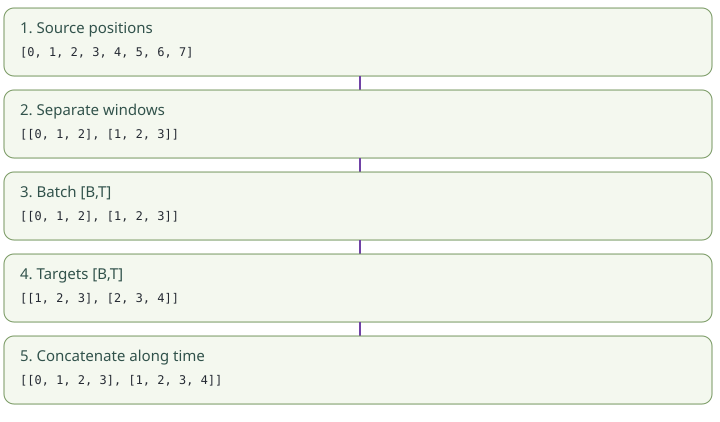

In [21]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

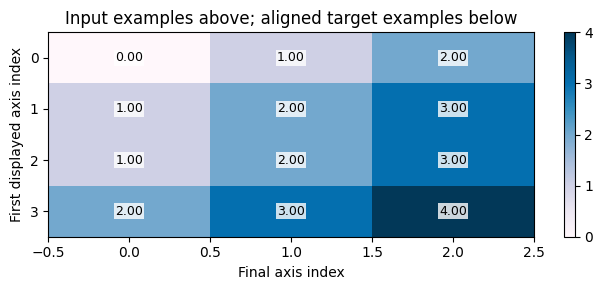

In [22]:
image = (torch.cat([x,y], dim=0).float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Input examples above; aligned target examples below'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.4.3 · Read and run the code

The comprehension slices the stream once per start. Stack requires the windows to have matching shapes before it can introduce a batch axis.

A short slice at the end of a stream can therefore break batch construction. Validate that every start leaves room for its final target.

Cat requires all axes other than the chosen concatenation axis to match. Keeping a one-position slice makes the appended target two-dimensional.

Split divides an existing axis into pieces; chunk requests a number of chunks. Check the resulting sizes instead of assuming every requested division is exact.

Dataset and DataLoader offer another way to organize examples. The notebook shows that alternative, while the actual tiny training recipe samples windows directly.

### Change one thing

**Move both starts forward**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [23]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
stream = torch.arange(8)
starts = [1, 2] if change else [0, 1]
show("Source positions", stream)
windows = [stream[i:i+3] for i in starts]
show("Separate windows", torch.stack(windows))
x = torch.stack(windows, dim=0)
show("Batch [B,T]", x)
y = torch.stack([stream[i+1:i+4] for i in starts])
show("Targets [B,T]", y)
show("Concatenate along time", torch.cat([x, y[:, -1:]], dim=1))
assert x.shape == y.shape == (2, 3)

Source positions: [0, 1, 2, 3, 4, 5, 6, 7]
  shape [8] · torch.int64 · cpu
Separate windows: [[1, 2, 3], [2, 3, 4]]
  shape [2, 3] · torch.int64 · cpu
Batch [B,T]: [[1, 2, 3], [2, 3, 4]]
  shape [2, 3] · torch.int64 · cpu
Targets [B,T]: [[2, 3, 4], [3, 4, 5]]
  shape [2, 3] · torch.int64 · cpu
Concatenate along time: [[1, 2, 3, 4], [2, 3, 4, 5]]
  shape [2, 4] · torch.int64 · cpu


### A useful distinction

Stack creates a new axis. Cat changes the length of an existing one.

In [24]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(x, y)
xb, yb = next(iter(DataLoader(dataset, batch_size=2, shuffle=False)))
assert torch.equal(xb, x) and torch.equal(yb, y)
print("DataLoader batches examples; it must preserve each input/target pair.")
print("split:", [tuple(t.shape) for t in x.split(2, dim=1)])

DataLoader batches examples; it must preserve each input/target pair.
split: [(2, 2), (2, 1)]


### ✋ Your turn

Stack tensors [1,2] and [3,4] as two examples; put the resulting nested list in answer.

In [25]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[1,2],[3,4]], 'Stack creates a new axis. Cat changes the length of an existing one.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [26]:
#@title Show a solution { display-mode: "form" }
answer = torch.stack([torch.tensor([1,2]), torch.tensor([3,4])]).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[1,2],[3,4]], 'Stack creates a new axis. Cat changes the length of an existing one.'
    print("✓ right:", answer)

✓ right: [[1, 2], [3, 4]]


### P1.4.4 · Find it in the model

Our training loop draws starts from an encoded stream and stacks their windows. The batch axis controls how many examples contribute to a step.

Context length controls the number of time positions in each example. Increasing batch size and increasing context length change different axes and different costs.

Padding is needed when combining unequal lengths by a chosen batching policy. The fixed-length character sampler avoids that particular requirement.

Phyll's data pipeline introduces special tokens and padding masks. The meaning of stack, cat and the next-target shift remains the same.

Next, reorganize values within a tensor while tracking which original coordinate each value came from.

```python
x = torch.stack([data[i:i+context] for i in starts])
y = torch.stack([data[i+1:i+context+1] for i in starts])
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which operation adds a new batch axis?

<details><summary>Check your explanation</summary>

stack. Stack creates a new axis. Cat changes the length of an existing one.

</details>

## P1.5 · Reshape without losing meaning

Reshape changes grouping; transpose and permute change axis order. A view can share storage with its source.

**Prerequisites:** Assemble sequences and batches

**Predict:** Are reshape(3,2) and transpose of [2,3] generally equal?

**Mental model:** Attention splits features into heads and later joins the heads again. A shape change is correct only if each value keeps the intended coordinate meaning.

### P1.5.1 · Understand the need

Attention splits features into heads and later joins the heads again. A shape change is correct only if each value keeps the intended coordinate meaning.

Reshape reads the values in their logical order and groups them into a new shape. Transpose instead exchanges the meaning of two axes.

Both operations can produce a three-by-two result from the same two-by-three input. Matching shapes therefore cannot prove that the transformations are equivalent.

Views can share storage. Strides describe how an index advances through that storage, and a requested view must be compatible with the existing layout.

Follow numbered values through the transformation. This is more informative than memorizing a sequence of reshape calls.

### P1.5.2 · Follow the values

The first matrix contains zero, one, two across its first line and three, four, five across its second.

Reshape groups the logical sequence into pairs: zero with one, two with three, and four with five.

Transpose exchanges the axes. Its first pair is zero with three, then one with four, then two with five. The same shape now contains a different arrangement.

Inspect strides: the original advances by three and one; its transpose advances by one and three. The transpose shares storage and is not contiguous in this layout.

Make a contiguous tensor in the transposed order, then flatten it with view. The sequence is zero, three, one, four, two, five. Adding ten changes values without changing these relationships.

In [27]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(6).reshape(2, 3) + (10 if change else 0)
show("Original [2,3]", x)
show("Reshape [3,2]", x.reshape(3, 2))
y = x.transpose(0, 1)
show("Transpose [3,2]", y)
show("Layout", {"x stride": list(x.stride()), "y stride": list(y.stride()), "y contiguous": y.is_contiguous()})
packed = y.contiguous().view(-1)
show("Pack transposed order", packed)
assert not torch.equal(x.reshape(3, 2), y)

Original [2,3]: [[0, 1, 2], [3, 4, 5]]
  shape [2, 3] · torch.int64 · cpu
Reshape [3,2]: [[0, 1], [2, 3], [4, 5]]
  shape [3, 2] · torch.int64 · cpu
Transpose [3,2]: [[0, 3], [1, 4], [2, 5]]
  shape [3, 2] · torch.int64 · cpu
Layout: {"x stride": [3, 1], "y stride": [1, 3], "y contiguous": false}
Pack transposed order: [0, 3, 1, 4, 2, 5]
  shape [6] · torch.int64 · cpu


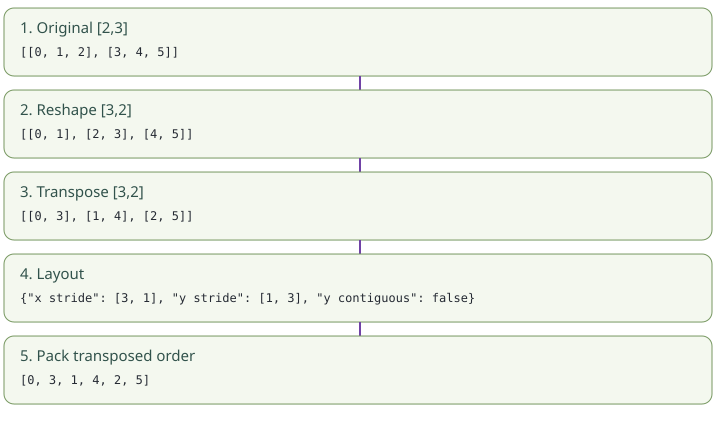

In [28]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

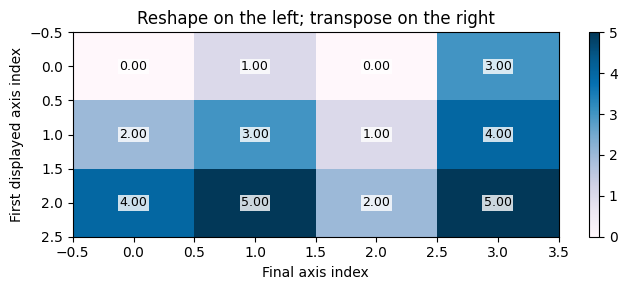

In [29]:
image = (torch.cat([x.reshape(3,2), x.T], dim=1).float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Reshape on the left; transpose on the right'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.5.3 · Read and run the code

Use reshape when the requested shape preserves the number of elements. A single minus one lets the library infer one axis from the others.

Use transpose to exchange two axes and permute to specify an entire axis order. Neither operation means calculate a new learned transformation.

View requires a compatible size and stride layout. Reshape can return a view or make a copy, so do not depend on it always sharing storage.

Contiguous preserves logical values while providing contiguous storage when a copy is needed. Clone explicitly makes independent storage, while detach addresses gradient recording.

Unsqueeze inserts a length-one axis. Squeeze with a specified axis avoids accidentally removing a batch axis when the batch size happens to be one.

### Change one thing

**Add ten to every source value**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [30]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(6).reshape(2, 3) + (10 if change else 0)
show("Original [2,3]", x)
show("Reshape [3,2]", x.reshape(3, 2))
y = x.transpose(0, 1)
show("Transpose [3,2]", y)
show("Layout", {"x stride": list(x.stride()), "y stride": list(y.stride()), "y contiguous": y.is_contiguous()})
packed = y.contiguous().view(-1)
show("Pack transposed order", packed)
assert not torch.equal(x.reshape(3, 2), y)

Original [2,3]: [[10, 11, 12], [13, 14, 15]]
  shape [2, 3] · torch.int64 · cpu
Reshape [3,2]: [[10, 11], [12, 13], [14, 15]]
  shape [3, 2] · torch.int64 · cpu
Transpose [3,2]: [[10, 13], [11, 14], [12, 15]]
  shape [3, 2] · torch.int64 · cpu
Layout: {"x stride": [3, 1], "y stride": [1, 3], "y contiguous": false}
Pack transposed order: [10, 13, 11, 14, 12, 15]
  shape [6] · torch.int64 · cpu


### A useful distinction

Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.

In [31]:
x = torch.arange(6).reshape(2,3)
y = x.T
try:
    y.view(-1)
except RuntimeError:
    print("This flattened view is incompatible with the transposed strides.")
alias = x.view(-1); alias[0] = 99
assert x[0,0].item() == 99
copied = x.clone(); copied[0,0] = -1
assert x[0,0].item() == 99
assert torch.zeros(1,2,1).squeeze(-1).shape == (1,2)

This flattened view is incompatible with the transposed strides.


### ✋ Your turn

Transpose torch.arange(6).reshape(2,3), then flatten in transposed order; put the list in answer.

In [32]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [0,3,1,4,2,5], 'Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [33]:
#@title Show a solution { display-mode: "form" }
answer = torch.arange(6).reshape(2,3).T.contiguous().view(-1).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [0,3,1,4,2,5], 'Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.'
    print("✓ right:", answer)

✓ right: [0, 3, 1, 4, 2, 5]


### P1.5.4 · Find it in the model

Queries begin with shape batch by time by features. The model groups features into heads, then transposes time and heads to obtain the attention layout.

After the weighted value mixture, it reverses that organization. The transpose is followed by contiguous and view to merge heads into a feature vector per token.

Phyll starts with a fused query-key-value projection and introduces a fifth axis before permuting it. Every step must preserve which values belong to which projection and head.

An incorrect reshape can run without an exception while mixing those meanings. Verify both the output shape and a few original coordinates.

Next, learn when PyTorch can expand a smaller shape across a larger one without changing those axis meanings.

```python
q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Are reshape(3,2) and transpose of [2,3] generally equal?

<details><summary>Check your explanation</summary>

No; grouping and axis exchange differ. Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.

</details>

# Section 2 · Calculate and build

- P1.6 · Elementwise operations and broadcasting
- P1.7 · Reduce along the right axis
- P1.8 · Matrix multiplication and linear layers
- P1.9 · Embeddings and positions
- P1.10 · Modules, parameters, and model state

## P1.6 · Elementwise operations and broadcasting

Broadcasting aligns trailing axes; compatible lengths are equal or one. Meaning must match as well as size.

**Prerequisites:** Reshape without losing meaning

**Predict:** Which bias shape adds a separate offset to each token in [2,3]?

**Mental model:** A linear layer adds one bias per output feature to every token vector. Writing an explicit loop over all tokens would repeat the same instruction.

### P1.6.1 · Understand the need

A linear layer adds one bias per output feature to every token vector. Writing an explicit loop over all tokens would repeat the same instruction.

Broadcasting lets a smaller tensor participate in an elementwise operation by aligning its trailing axes with the larger tensor.

Equal lengths match directly. A length-one axis can expand across the corresponding axis, and missing leading axes act like length one.

Valid broadcasting does not prove that the operation matches your intention. A token offset and a feature bias can require different singleton axes.

Name the axes first, then inspect the sizes. This prevents errors that produce plausible-looking values without raising an exception.

### P1.6.2 · Follow the values

The input has two token vectors, each with three features. The values zero through five identify which entries receive an addition.

The feature bias contains ten, twenty and thirty. Its three-entry axis aligns with the final feature axis of the input.

Adding it gives ten, twenty-one and thirty-two for the first token; thirteen, twenty-four and thirty-five for the second. The same feature bias is reused.

A token offset instead has shape two by one, with offsets 100 and 200. Its singleton feature axis expands across all three features.

The resulting vectors receive different common offsets. Double the feature bias in the experiment and compare which output changes; the separate token-offset operation stays fixed.

In [34]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(6, dtype=torch.float32).reshape(2,3)
show("Two token vectors", x)
bias = torch.tensor([10.,20.,30.]) * (2 if change else 1)
show("Feature bias [3]", bias)
show("Bias shared over tokens", x + bias)
offset = torch.tensor([[100.],[200.]])
show("Token offset [2,1]", offset)
show("Offset shared over features", x + offset)

Two token vectors: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0]]
  shape [2, 3] · torch.float32 · cpu
Feature bias [3]: [10.0, 20.0, 30.0]
  shape [3] · torch.float32 · cpu
Bias shared over tokens: [[10.0, 21.0, 32.0], [13.0, 24.0, 35.0]]
  shape [2, 3] · torch.float32 · cpu
Token offset [2,1]: [[100.0], [200.0]]
  shape [2, 1] · torch.float32 · cpu
Offset shared over features: [[100.0, 101.0, 102.0], [203.0, 204.0, 205.0]]
  shape [2, 3] · torch.float32 · cpu


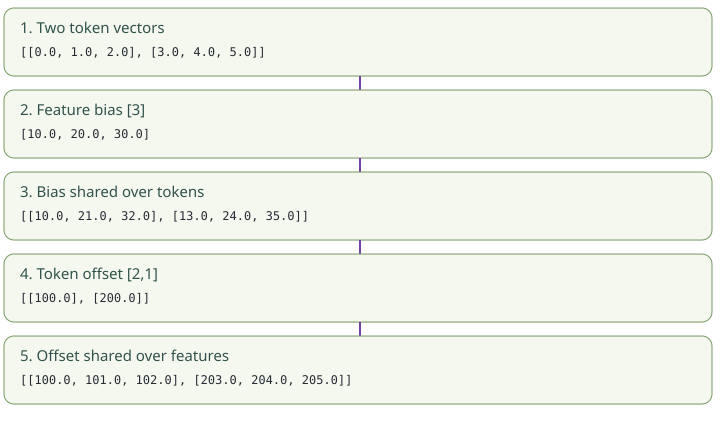

In [35]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

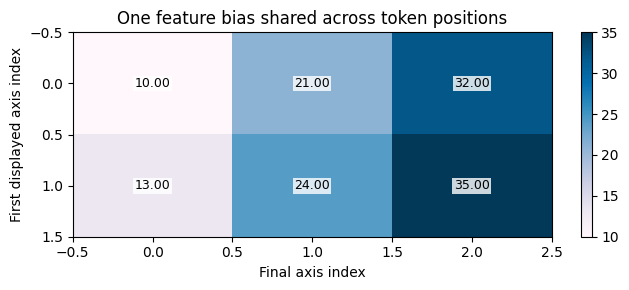

In [36]:
image = (x + bias).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('One feature bias shared across token positions'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.6.3 · Read and run the code

Read the shapes from right to left before applying plus or elementwise multiplication. Every aligned pair must match or contain a one.

Add a singleton axis when it expresses the intended sharing. Unsqueezing the wrong axis can either fail or silently apply an offset to the wrong axis.

A broadcast operation does not imply that a smaller tensor was learned separately at every expanded position. Shared parameters remain shared.

In-place operations have additional constraints: the destination cannot expand itself to accommodate a larger broadcast result. Prefer clear out-of-place expressions while learning.

Test an invalid shape and a misleading valid shape. Understanding both is more useful than memorizing one successful bias example.

### Change one thing

**Double the feature bias**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [37]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(6, dtype=torch.float32).reshape(2,3)
show("Two token vectors", x)
bias = torch.tensor([10.,20.,30.]) * (2 if change else 1)
show("Feature bias [3]", bias)
show("Bias shared over tokens", x + bias)
offset = torch.tensor([[100.],[200.]])
show("Token offset [2,1]", offset)
show("Offset shared over features", x + offset)

Two token vectors: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0]]
  shape [2, 3] · torch.float32 · cpu
Feature bias [3]: [20.0, 40.0, 60.0]
  shape [3] · torch.float32 · cpu
Bias shared over tokens: [[20.0, 41.0, 62.0], [23.0, 44.0, 65.0]]
  shape [2, 3] · torch.float32 · cpu
Token offset [2,1]: [[100.0], [200.0]]
  shape [2, 1] · torch.float32 · cpu
Offset shared over features: [[100.0, 101.0, 102.0], [203.0, 204.0, 205.0]]
  shape [2, 3] · torch.float32 · cpu


### A useful distinction

A broadcast can be legal and still express the wrong axis meaning.

In [38]:
try:
    torch.zeros(2,3) + torch.zeros(2)
except RuntimeError:
    print("Trailing lengths 3 and 2 cannot broadcast.")
else:
    raise AssertionError("Expected incompatible shapes")

Trailing lengths 3 and 2 cannot broadcast.


### ✋ Your turn

Add a feature bias [10,20,30] to zeros shaped [2,3] and put the nested list in answer.

In [39]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[10,20,30],[10,20,30]], 'A broadcast can be legal and still express the wrong axis meaning.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [40]:
#@title Show a solution { display-mode: "form" }
answer = (torch.zeros(2,3) + torch.tensor([10,20,30])).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[10,20,30],[10,20,30]], 'A broadcast can be legal and still express the wrong axis meaning.'
    print("✓ right:", answer)

✓ right: [[10.0, 20.0, 30.0], [10.0, 20.0, 30.0]]


### P1.6.4 · Find it in the model

Token vectors have batch, time and feature axes. A position table lookup produces time by feature values that are shared across the batch axis.

A linear bias has one feature axis and is shared across batch and time. These are two distinct uses of the same broadcasting rules.

Attention's causal permission matrix can be shared across batches and heads by adding singleton leading axes. Its time axes still have specific query and key meanings.

Gradients from repeated uses of a shared parameter accumulate into its original shape. Broadcasting does not create independently learned copies.

Next, move in the other direction: reduce an axis into a sum, average or selected maximum.

```python
x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which bias shape adds a separate offset to each token in [2,3]?

<details><summary>Check your explanation</summary>

[2,1]. A broadcast can be legal and still express the wrong axis meaning.

</details>

## P1.7 · Reduce along the right axis

A reduction combines the selected axis. keepdim preserves a singleton axis for a later broadcast.

**Prerequisites:** Elementwise operations and broadcasting

**Predict:** Which variance correction matches LayerNorm?

**Mental model:** Taking a mean is incomplete until you say which values are averaged together. A tensor can contain several axes with different meanings.

### P1.7.1 · Understand the need

Taking a mean is incomplete until you say which values are averaged together. A tensor can contain several axes with different meanings.

Averaging features within each token produces one value per token. Averaging all entries instead produces one scalar for the entire tensor.

Keepdim retains the reduced axis at length one. That makes it align correctly when a result is subtracted from the original tensor.

Max and argmax answer different questions: the largest value versus the index where a largest value appears. An index can later identify a predicted token.

Trace the remaining axes after each reduction. This prepares normalization, loss averaging and accuracy measurement.

### P1.7.2 · Follow the values

The two token vectors are two, zero, one and five, three, four. Each has three features.

Their feature means are one and four. Keeping the final axis produces a two-by-one result.

Subtract the matching mean from each vector. Both centered vectors become one, minus one and zero.

The population variance is two thirds for each vector. Correction zero divides the squared deviations by the number of features.

The whole tensor mean is 2.5, while feature-wise means answer a different question. Adding ten to every input shifts the means but leaves centered vectors and variances unchanged.

In [41]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[5.,3.,4.]]) + (10 if change else 0)
show("Two token vectors", x)
means = x.mean(dim=-1, keepdim=True)
show("One mean per token [2,1]", means)
show("Centered vectors", x-means)
show("Population variance per token", x.var(dim=-1, correction=0))
show("Different questions", {"whole tensor mean": x.mean().item(), "feature means": x.mean(dim=0).tolist(), "largest feature index": x.argmax(dim=-1).tolist()})

Two token vectors: [[2.0, 0.0, 1.0], [5.0, 3.0, 4.0]]
  shape [2, 3] · torch.float32 · cpu
One mean per token [2,1]: [[1.0], [4.0]]
  shape [2, 1] · torch.float32 · cpu
Centered vectors: [[1.0, -1.0, 0.0], [1.0, -1.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Population variance per token: [0.6666666865348816, 0.6666666865348816]
  shape [2] · torch.float32 · cpu
Different questions: {"whole tensor mean": 2.5, "feature means": [3.5, 1.5, 2.5], "largest feature index": [0, 0]}


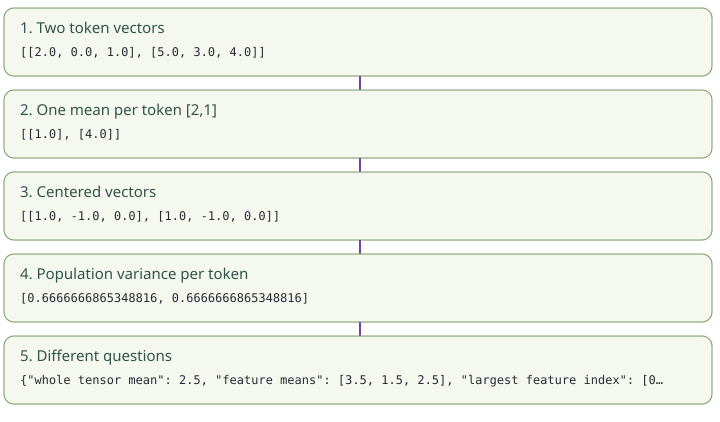

In [42]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

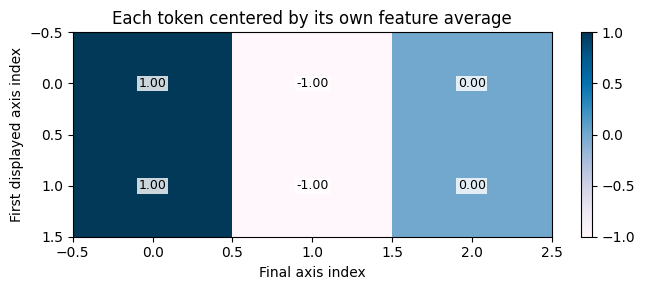

In [43]:
image = (x-means).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Each token centered by its own feature average'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.7.3 · Read and run the code

Use dim minus one to reduce the feature axis in this example. Keepdim makes its output broadcastable back across that axis.

Mean without dim combines all entries. That is appropriate only when the intended weighting really gives every included entry equal weight.

Variance uses a correction setting. LayerNorm's variance uses correction zero, which differs from torch var's default sample correction.

Argmax returns indices. If scores are tied, do not infer a unique preferred class from equal values; inspect the API's tie behavior when it matters.

Boolean comparisons can be reduced to counts or mean accuracy after conversion. Keep the denominator aligned with the set of valid targets.

### Change one thing

**Add ten to all features**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [44]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[5.,3.,4.]]) + (10 if change else 0)
show("Two token vectors", x)
means = x.mean(dim=-1, keepdim=True)
show("One mean per token [2,1]", means)
show("Centered vectors", x-means)
show("Population variance per token", x.var(dim=-1, correction=0))
show("Different questions", {"whole tensor mean": x.mean().item(), "feature means": x.mean(dim=0).tolist(), "largest feature index": x.argmax(dim=-1).tolist()})

Two token vectors: [[12.0, 10.0, 11.0], [15.0, 13.0, 14.0]]
  shape [2, 3] · torch.float32 · cpu
One mean per token [2,1]: [[11.0], [14.0]]
  shape [2, 1] · torch.float32 · cpu
Centered vectors: [[1.0, -1.0, 0.0], [1.0, -1.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Population variance per token: [0.6666666865348816, 0.6666666865348816]
  shape [2] · torch.float32 · cpu
Different questions: {"whole tensor mean": 12.5, "feature means": [13.5, 11.5, 12.5], "largest feature index": [0, 0]}


### A useful distinction

torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.

### ✋ Your turn

Center each token in [[1,3],[10,14]] using its own feature mean; put the nested list in answer.

In [45]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[-1,1],[-2,2]], 'torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [46]:
#@title Show a solution { display-mode: "form" }
x = torch.tensor([[1.,3.],[10.,14.]])
answer = (x - x.mean(-1, keepdim=True)).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[-1,1],[-2,2]], 'torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.'
    print("✓ right:", answer)

✓ right: [[-1.0, 1.0], [-2.0, 2.0]]


### P1.7.4 · Find it in the model

LayerNorm computes statistics across the feature axes it is configured to normalize. It does not automatically average across the batch.

Cross-entropy can return a loss for each target or reduce those losses. Padding changes which target positions should contribute to an average.

Accuracy compares predicted IDs with target IDs and counts matches. It is a different measurement from the probabilities used by cross-entropy.

Averaging batch averages is only correct when their effective counts are equal or appropriately weighted. The training unit develops this aggregation rule.

Next, learn a calculation that combines two axes through products: matrix multiplication.

```python
mean = x.mean(dim=-1, keepdim=True)
variance = x.var(dim=-1, correction=0, keepdim=True)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which variance correction matches LayerNorm?

<details><summary>Check your explanation</summary>

0. torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.

</details>

## P1.8 · Matrix multiplication and linear layers

Matrix multiplication contracts the shared feature axis. Leading axes organize independent or broadcast products.

**Prerequisites:** Reduce along the right axis

**Predict:** What shape does [2,3] @ [3,4] produce?

**Mental model:** A linear layer combines an input vector's features into a new vector. Each output feature uses its own weighted sum of the input features.

<a id="pytorch-matmul-op"></a>

<a data-compat-cell="p1-and-broadcasting"></a>

### P1.8.1 · Understand the need

A linear layer combines an input vector's features into a new vector. Each output feature uses its own weighted sum of the input features.

Elementwise multiplication keeps the separate products. A dot product additionally sums them into one score.

Matrix multiplication performs many such dot products with a defined arrangement of input and output axes. The contracted inner sizes must match.

PyTorch stores a linear layer's weights as output features by input features. The calculation therefore multiplies the input by the transposed weight and adds a bias.

Attention adds leading batch and head axes. The last two axes still perform matrix multiplication while compatible leading axes organize the products.

### P1.8.2 · Follow the values

The first input vector is two, zero and one. The first output's weights are one, three and minus one.

The full weight has two outputs and three inputs. Each of its two vectors describes a different output feature.

Multiply the first input with the first weight vector entry by entry. The contributions are two, zero and minus one, summing to one.

The complete matrix product contains both output features for both input vectors. Its shape is two by two because the shared input axis has been contracted.

Add the feature biases, one half and minus one half. Doubling the input doubles the product but does not double the independently added bias.

In [47]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[1.,2.,0.]]) * (2 if change else 1)
weight = torch.tensor([[1.,3.,-1.],[0.,2.,1.]])
bias = torch.tensor([.5,-.5])
show("Input [2,3]", x)
show("Weight stored [out,in]", weight)
show("Contributions to output [0,0]", x[0]*weight[0])
show("Product before bias", x @ weight.T)
show("Linear output", F.linear(x, weight, bias))
torch.testing.assert_close(F.linear(x, weight, bias), x @ weight.T + bias)

Input [2,3]: [[2.0, 0.0, 1.0], [1.0, 2.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Weight stored [out,in]: [[1.0, 3.0, -1.0], [0.0, 2.0, 1.0]]
  shape [2, 3] · torch.float32 · cpu
Contributions to output [0,0]: [2.0, 0.0, -1.0]
  shape [3] · torch.float32 · cpu
Product before bias: [[1.0, 1.0], [7.0, 4.0]]
  shape [2, 2] · torch.float32 · cpu
Linear output: [[1.5, 0.5], [7.5, 3.5]]
  shape [2, 2] · torch.float32 · cpu


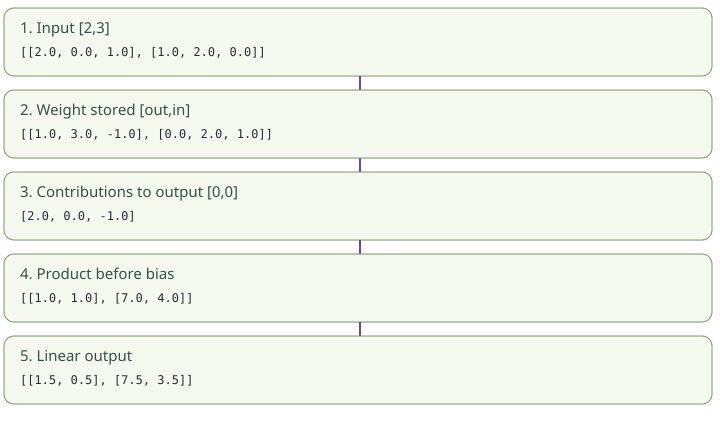

In [48]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

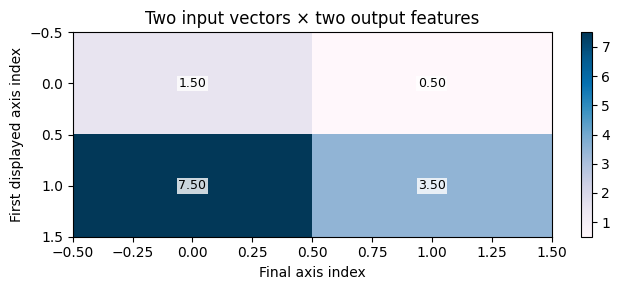

In [49]:
image = (F.linear(x,weight,bias)).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Two input vectors × two output features'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.8.3 · Read and run the code

The at operator performs matmul; the star operator performs elementwise multiplication. Use distinct examples to make their different output shapes visible.

Transpose this two-dimensional weight so its input axis meets the input tensor's final axis. For tensors with more axes, choose transpose axes explicitly.

Functional linear computes the same operation as a linear module using the supplied weight and bias. Compare the two calculations with assert close.

A linear module owns those parameters and registers them for an optimizer. It applies the same learned transformation to every leading batch and time position.

Batched matmul broadcasts compatible leading axes of both operands. The interactive shape explorer checks that rule before attempting the contracted product.

### Change one thing

**Double the input; keep bias fixed**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [50]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[1.,2.,0.]]) * (2 if change else 1)
weight = torch.tensor([[1.,3.,-1.],[0.,2.,1.]])
bias = torch.tensor([.5,-.5])
show("Input [2,3]", x)
show("Weight stored [out,in]", weight)
show("Contributions to output [0,0]", x[0]*weight[0])
show("Product before bias", x @ weight.T)
show("Linear output", F.linear(x, weight, bias))
torch.testing.assert_close(F.linear(x, weight, bias), x @ weight.T + bias)

Input [2,3]: [[4.0, 0.0, 2.0], [2.0, 4.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Weight stored [out,in]: [[1.0, 3.0, -1.0], [0.0, 2.0, 1.0]]
  shape [2, 3] · torch.float32 · cpu
Contributions to output [0,0]: [4.0, 0.0, -2.0]
  shape [3] · torch.float32 · cpu
Product before bias: [[2.0, 2.0], [14.0, 8.0]]
  shape [2, 2] · torch.float32 · cpu
Linear output: [[2.5, 1.5], [14.5, 7.5]]
  shape [2, 2] · torch.float32 · cpu


### A useful distinction

A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.

In [51]:
q = torch.arange(2*2*3*2, dtype=torch.float32).reshape(2,2,3,2)
k = torch.ones(1,2,4,2)
scores = q @ k.transpose(-2,-1)
assert scores.shape == (2,2,3,4)
for b in range(2):
    for h in range(2):
        torch.testing.assert_close(scores[b,h], q[b,h] @ k[0,h].T)
print("Both operands can have batch axes:", tuple(scores.shape))

Both operands can have batch axes: (2, 2, 3, 4)


### ✋ Your turn

For x=[2,0,1] and weight=[1,3,-1], calculate their dot product and put its scalar in answer.

In [52]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 1, 'A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [53]:
#@title Show a solution { display-mode: "form" }
answer = (torch.tensor([2.,0.,1.]) @ torch.tensor([1.,3.,-1.])).item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 1, 'A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.'
    print("✓ right:", answer)

✓ right: 1.0


### P1.8.4 · Find it in the model

The query-key-value projection maps each of the current model's twenty-eight features to eighty-four outputs. The three groups later become separate queries, keys and values.

Attention scores multiply queries by transposed keys. The final feature axes meet, leaving query positions and key positions as the score matrix axes.

Multiplying those scores' normalized shares by values contracts the key-position axis, returning one value mixture per query position.

The readout reuses the token embedding table as a weight. This creates a vocabulary score for each token position without a separately learned table.

Next, inspect the lookup operation that uses that same table in the input direction.

```python
att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
y = att @ v
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What shape does [2,3] @ [3,4] produce?

<details><summary>Check your explanation</summary>

[2,4]. A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.

</details>

## P1.9 · Embeddings and positions

An embedding selects a learned vector by ID. A learned position lookup adds information about the token’s slot.

**Prerequisites:** Matrix multiplication and linear layers

**Predict:** Does repeating an ID select the same token vector before position addition?

**Mental model:** An ID is a discrete label. An embedding table supplies the floating-point vector that the transformer uses to represent that label.

### P1.9.1 · Understand the need

An ID is a discrete label. An embedding table supplies the floating-point vector that the transformer uses to represent that label.

Lookup selects one learned vector for each input ID. The input's axes are preserved and a feature axis is appended.

Repeating an ID selects the same token vector before context-dependent processing. Appearing in a different position does not by itself change that lookup.

A separate position table selects a vector for the slot. Adding it gives the model's later operations access to both token identity and position information.

The values in this example are set by hand for inspection. In the actual model, training learns the table entries.

### P1.9.2 · Follow the values

The input contains one sequence of three IDs: one, one and three. Repeating one makes the repeated lookup visible.

The token table contains four vectors of three features. ID one selects the vector three, four and five.

The first two token vectors are equal, while ID three selects nine, ten and eleven. The result has batch, time and feature axes.

Position zero adds zeros in this illustration. Position one adds one tenth, two tenths and three tenths; position two has its own vector.

The equal token vectors now produce different sums because their slots differ. Change the second token ID and observe token identity changing independently from its slot.

In [54]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
table = nn.Embedding(4, 3)
positions = nn.Embedding(3, 3)
with torch.no_grad():
    table.weight.copy_(torch.arange(12).reshape(4,3).float())
    positions.weight.copy_(torch.tensor([[0.,0.,0.],[.1,.2,.3],[.4,.5,.6]]))
ids = torch.tensor([[1, 2 if change else 1, 3]])
show("Input IDs [1,3]", ids)
show("Illustrative lookup table [4,3]", table.weight)
tokens = table(ids)
show("Selected token vectors [1,3,3]", tokens)
pos = positions(torch.arange(ids.size(1)))
show("Position vectors [3,3]", pos)
show("Token plus position", tokens + pos)

Input IDs [1,3]: [[1, 1, 3]]
  shape [1, 3] · torch.int64 · cpu
Illustrative lookup table [4,3]: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0], [9.0, 10.0, 11.0]]
  shape [4, 3] · torch.float32 · cpu


Selected token vectors [1,3,3]: [[[3.0, 4.0, 5.0], [3.0, 4.0, 5.0], [9.0, 10.0, 11.0]]]
  shape [1, 3, 3] · torch.float32 · cpu
Position vectors [3,3]: [[0.0, 0.0, 0.0], [0.10000000149011612, 0.20000000298023224, 0.30000001192092896], [0.4000000059604645, 0.5, 0.6000000238418579]]
  shape [3, 3] · torch.float32 · cpu
Token plus position: [[[3.0, 4.0, 5.0], [3.0999999046325684, 4.199999809265137, 5.300000190734863], [9.399999618530273, 10.5, 11.600000381469727]]]
  shape [1, 3, 3] · torch.float32 · cpu


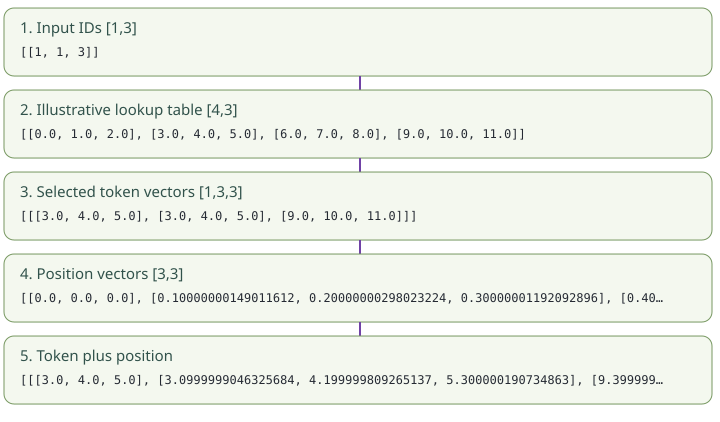

In [55]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

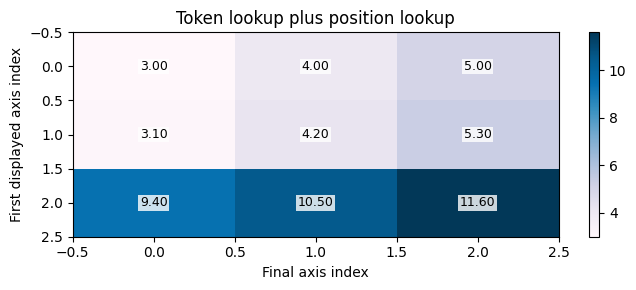

In [56]:
image = ((tokens+pos)[0]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Token lookup plus position lookup'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.9.3 · Read and run the code

Construct Embedding with a vocabulary size and a feature width. Its weight parameter stores one feature vector per permitted ID.

The no-grad block sets hand-sized example weights without recording these assignments for differentiation. These are illustrative values, not a trained checkpoint.

Pass an integer ID tensor into the table. The output shape is the input shape followed by the embedding width.

Arange creates position IDs for the available time positions. The resulting time-by-feature tensor broadcasts across the batch when added to token vectors.

Check ID bounds and the maximum position index. Neither a larger vocabulary table nor a larger position table is created automatically when an index exceeds its size.

### Change one thing

**Change the second ID from 1 to 2**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [57]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
table = nn.Embedding(4, 3)
positions = nn.Embedding(3, 3)
with torch.no_grad():
    table.weight.copy_(torch.arange(12).reshape(4,3).float())
    positions.weight.copy_(torch.tensor([[0.,0.,0.],[.1,.2,.3],[.4,.5,.6]]))
ids = torch.tensor([[1, 2 if change else 1, 3]])
show("Input IDs [1,3]", ids)
show("Illustrative lookup table [4,3]", table.weight)
tokens = table(ids)
show("Selected token vectors [1,3,3]", tokens)
pos = positions(torch.arange(ids.size(1)))
show("Position vectors [3,3]", pos)
show("Token plus position", tokens + pos)

Input IDs [1,3]: [[1, 2, 3]]
  shape [1, 3] · torch.int64 · cpu
Illustrative lookup table [4,3]: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0], [9.0, 10.0, 11.0]]
  shape [4, 3] · torch.float32 · cpu
Selected token vectors [1,3,3]: [[[3.0, 4.0, 5.0], [6.0, 7.0, 8.0], [9.0, 10.0, 11.0]]]
  shape [1, 3, 3] · torch.float32 · cpu
Position vectors [3,3]: [[0.0, 0.0, 0.0], [0.10000000149011612, 0.20000000298023224, 0.30000001192092896], [0.4000000059604645, 0.5, 0.6000000238418579]]
  shape [3, 3] · torch.float32 · cpu
Token plus position: [[[3.0, 4.0, 5.0], [6.099999904632568, 7.199999809265137, 8.300000190734863], [9.399999618530273, 10.5, 11.600000381469727]]]
  shape [1, 3, 3] · torch.float32 · cpu


### A useful distinction

Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.

### ✋ Your turn

Select IDs [2,0] from a table torch.arange(6).reshape(3,2) and put the nested result in answer.

In [58]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[4,5],[0,1]], 'Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [59]:
#@title Show a solution { display-mode: "form" }
answer = torch.arange(6).reshape(3,2)[torch.tensor([2,0])].tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[4,5],[0,1]], 'Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.'
    print("✓ right:", answer)

✓ right: [[4, 5], [0, 1]]


### P1.9.4 · Find it in the model

Our current model has sixty-five token vectors, each with twenty-eight features, and a separate table for thirty-two positions. Both tables are learned.

These position vectors come from lookup, not a sine formula. The course's mathematics collection explains that calculation and compares positional approaches where appropriate.

The token table is also used in the final readout. Its two uses contribute gradients to the same learned parameter during training.

Phyll uses larger tables and special token IDs. An embedding padding option and an ignored loss target are separate mechanisms and should not be conflated.

Next, inspect how modules register these parameters and keep their state organized.

```python
self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)
x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does repeating an ID select the same token vector before position addition?

<details><summary>Check your explanation</summary>

Yes. Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.

</details>

## P1.10 · Modules, parameters, and model state

Modules register learned parameters and buffers. Shared parameters are one object even when several modules use them.

**Prerequisites:** Embeddings and positions

**Predict:** What proves two layers are tied?

**Mental model:** A neural network module combines a calculation with registered state. Registration lets the library find parameters for optimization, device movement and saving.

<a data-compat-cell="p1-modules"></a>

### P1.10.1 · Understand the need

A neural network module combines a calculation with registered state. Registration lets the library find parameters for optimization, device movement and saving.

An ordinary tensor attribute is not automatically a learned parameter. Parameter marks a tensor for that role, while buffers represent other module state.

A list of layers also needs registration. ModuleList keeps its contained layers visible to the parent module's parameter traversal.

Weight tying deliberately makes two uses refer to one parameter object. Counting names in a saved dictionary can therefore differ from counting unique learned values.

Inspect registration before training. A calculation may run while an accidentally unregistered weight never reaches the optimizer.

### P1.10.2 · Follow the values

The model holds a four-entry embedding, a small linear transformation and a four-entry output bias. The parameter listing shows their individual shapes.

The allowed tensor appears among buffers. It moves with the module but is not a learned parameter, and this nonpersistent buffer is excluded from the saved state dictionary.

The readout weight refers to the embedding's parameter object. Identity is true: these are two uses of shared state.

With width three, the unique parameter count is twenty-eight. The shared embedding contributes twelve, the transformation twelve, and the output bias four.

Calling the module on one sequence of two IDs returns one-by-two-by-four scores. Increase width in the experiment and recount the internal state while preserving the output vocabulary size.

In [60]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
class TinyLookup(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.embedding = nn.Embedding(4, width)
        self.readout = nn.Linear(width, 4, bias=False)
        self.readout.weight = self.embedding.weight
        self.bias = nn.Parameter(torch.zeros(4))
        self.layers = nn.ModuleList([nn.Linear(width, width)])
        self.register_buffer("allowed", torch.ones(2,2,dtype=torch.bool), persistent=False)
    def forward(self, ids):
        x = self.embedding(ids)
        for layer in self.layers:
            x = layer(x)
        return self.readout(x) + self.bias
model = TinyLookup(4 if change else 3)
show("Registered parameter shapes", {n: list(p.shape) for n,p in model.named_parameters()})
show("Buffer names", [n for n,_ in model.named_buffers()])
show("Readout and embedding share one object", model.readout.weight is model.embedding.weight)
show("Unique parameter elements", sum(p.numel() for p in model.parameters()))
show("Call forward through the module", model(torch.tensor([[1,2]])).shape)

Registered parameter shapes: {"bias": [4], "embedding.weight": [4, 3], "layers.0.weight": [3, 3], "layers.0.bias": [3]}
Buffer names: ["allowed"]
Readout and embedding share one object: true
Unique parameter elements: 28
Call forward through the module: [1, 2, 4]


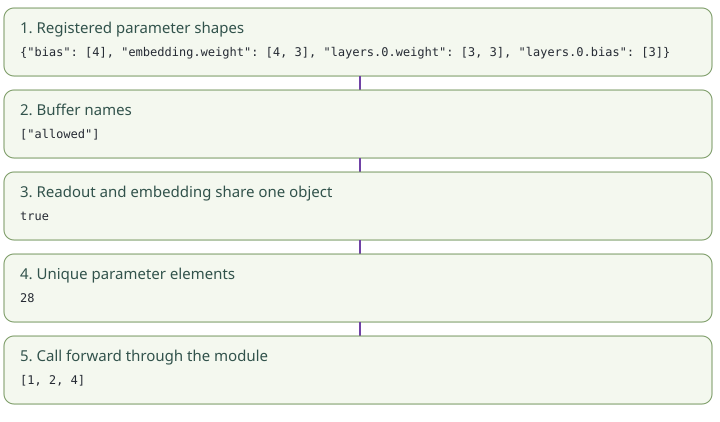

In [61]:
draw_trace()

### P1.10.3 · Read and run the code

Initialize the module base class with super before assigning registered submodules. The inherited machinery tracks those assignments.

Embedding and Linear create their own parameters. Wrapping the output bias in Parameter makes this explicitly created tensor discoverable too.

Assign the embedding parameter to the readout weight to share it. Copying equal numbers into an independent weight would not create the same relationship.

ModuleList registers the layer objects, but your forward method still decides how to call them. Sequential instead provides an ordered call chain for compatible modules.

Call model with parentheses so module call behavior surrounds forward. Use named parameters and named buffers to audit the state that saving and device movement will use.

### Change one thing

**Increase the illustrative feature width**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [62]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
class TinyLookup(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.embedding = nn.Embedding(4, width)
        self.readout = nn.Linear(width, 4, bias=False)
        self.readout.weight = self.embedding.weight
        self.bias = nn.Parameter(torch.zeros(4))
        self.layers = nn.ModuleList([nn.Linear(width, width)])
        self.register_buffer("allowed", torch.ones(2,2,dtype=torch.bool), persistent=False)
    def forward(self, ids):
        x = self.embedding(ids)
        for layer in self.layers:
            x = layer(x)
        return self.readout(x) + self.bias
model = TinyLookup(4 if change else 3)
show("Registered parameter shapes", {n: list(p.shape) for n,p in model.named_parameters()})
show("Buffer names", [n for n,_ in model.named_buffers()])
show("Readout and embedding share one object", model.readout.weight is model.embedding.weight)
show("Unique parameter elements", sum(p.numel() for p in model.parameters()))
show("Call forward through the module", model(torch.tensor([[1,2]])).shape)

Registered parameter shapes: {"bias": [4], "embedding.weight": [4, 4], "layers.0.weight": [4, 4], "layers.0.bias": [4]}
Buffer names: ["allowed"]
Readout and embedding share one object: true
Unique parameter elements: 40
Call forward through the module: [1, 2, 4]


### A useful distinction

Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.

### ✋ Your turn

Create nn.Linear(3,2) with its default bias and put its parameter element count in answer.

In [63]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 8, 'Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [64]:
#@title Show a solution { display-mode: "form" }
layer = nn.Linear(3,2)
answer = sum(p.numel() for p in layer.parameters())

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 8, 'Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.'
    print("✓ right:", answer)

✓ right: 8


### P1.10.4 · Find it in the model

Our current model registers token and position embeddings, transformer blocks, a final normalization layer and a vocabulary bias. Its readout directly reuses the token-table weight.

The causal mask is a nonpersistent buffer. It is derived from configuration, can move to the model's device, and need not be learned or stored as a parameter.

Initialization assigns starting values to parameters before training. A parameter is learnable state, not evidence that it has already been trained.

Phyll uses a registered list of blocks and explicitly ties its readout weight to the embedding. The same registration and identity checks apply.

Next, use these registered projections to assemble the actual attention tensors.

```python
self.head_bias = nn.Parameter(torch.zeros(cfg.vocab_size))
logits = x @ self.tok_emb.weight.T + self.head_bias
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What proves two layers are tied?

<details><summary>Check your explanation</summary>

They share the same parameter object. Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.

</details>

# Section 3 · Assemble the model

- P1.11 · Assemble attention tensors
- P1.12 · Feed-forward blocks and residual paths
- P1.13 · Predictions, targets, and loss
- P1.14 · Autograd follows the computation

## P1.11 · Assemble attention tensors

Attention scores compare queries and keys; a causal mask removes future positions before softmax mixes values.

**Prerequisites:** Modules, parameters, and model state

**Predict:** Changing a future value can affect an earlier causal query.

**Mental model:** A query needs a mixture of value vectors from permitted positions. Attention constructs the mixture weights from comparisons between queries and keys.

### P1.11.1 · Understand the need

A query needs a mixture of value vectors from permitted positions. Attention constructs the mixture weights from comparisons between queries and keys.

Each head performs these comparisons with its own feature vectors. Batch and head axes organize independent score matrices.

A causal model must not read future positions while predicting the next character. A mask marks those positions before probabilities are normalized.

Softmax converts permitted scores into nonnegative shares that sum to one over keys. Multiplying by values then forms a weighted mixture.

The calculation is useful to read before deriving every formula. The maths collection supplies the dot-product, scaling and softmax derivations.

### P1.11.2 · Follow the values

This example has one batch, two illustrative identical heads, three positions and two features per head. Inspect the first head's three query vectors.

Multiply queries by transposed keys and divide by the square root of the feature width. Each score now names one query-position and key-position pair.

The lower-triangular permission matrix allows the current position and its predecessors. Future positions are forbidden.

Replace forbidden scores with negative infinity before softmax. Their shares become zero, and every valid query's remaining shares sum to one.

Mix value vectors using those shares. Change only the final value vector in the experiment: earlier query outputs remain unchanged because their share for that future position is zero.

In [65]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
q = torch.tensor([[1.,0.],[0.,1.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
k = q.clone()
v = torch.tensor([[2.,0.],[0.,2.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
if change:
    v[:,:,2,:] += 10
show("Queries [B,H,T,Dh]", q)
scores = q @ k.transpose(-2,-1) / math.sqrt(2)
show("Scaled scores, first head", scores[0,0])
allowed = torch.ones(3,3,dtype=torch.bool).tril()
masked = scores.masked_fill(~allowed, float("-inf"))
show("Causal permissions", allowed)
shares = masked.softmax(dim=-1)
show("Shares over key positions", shares[0,0])
mixed = shares @ v
show("Mixtures, first head", mixed[0,0])
assert torch.equal(shares[0,0].triu(1), torch.zeros(3,3))

Queries [B,H,T,Dh]: [[[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]], [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]]
  shape [1, 2, 3, 2] · torch.float32 · cpu
Scaled scores, first head: [[0.7071067690849304, 0.0, 0.7071067690849304], [0.0, 0.7071067690849304, 0.7071067690849304], [0.7071067690849304, 0.7071067690849304, 1.4142135381698608]]
  shape [3, 3] · torch.float32 · cpu
Causal permissions: [[true, false, false], [true, true, false], [true, true, true]]
  shape [3, 3] · torch.bool · cpu
Shares over key positions: [[1.0, 0.0, 0.0], [0.3302384614944458, 0.6697615385055542, 0.0], [0.24825508892536163, 0.24825508892536163, 0.5034898519515991]]
  shape [3, 3] · torch.float32 · cpu
Mixtures, first head: [[2.0, 0.0], [0.6604769229888916, 1.3395230770111084], [1.0, 1.0]]
  shape [3, 2] · torch.float32 · cpu


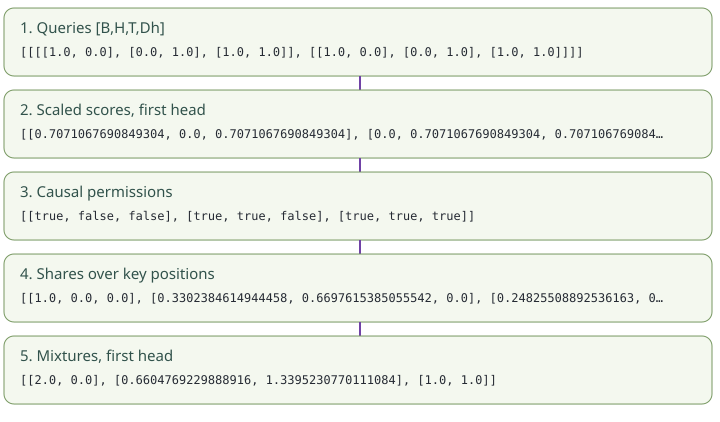

In [66]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

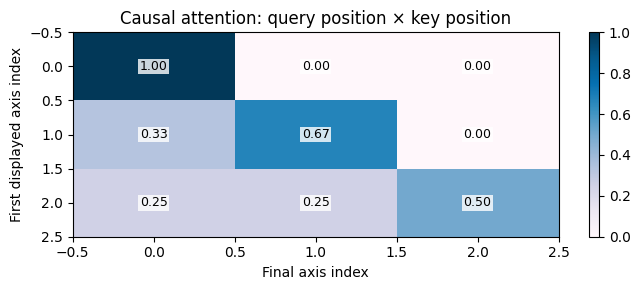

In [67]:
image = (shares[0,0]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Causal attention: query position × key position'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.11.3 · Read and run the code

The final two axes of query and key meet through a batched matrix product. Transpose only the key's feature and time axes.

Construct a Boolean triangular permission matrix. Negating that matrix identifies the entries masked fill must replace.

Softmax uses the final key-position axis. Normalizing across batches or query positions would express a different operation.

Multiply the shares by value vectors, then restore time before heads and merge the head-feature axes. Preserve coordinate meaning at every reshape.

Every query needs at least one allowed key. An entirely masked score vector has no valid probability distribution and produces invalid softmax results.

### Change one thing

**Change only the last value vector**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [68]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
q = torch.tensor([[1.,0.],[0.,1.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
k = q.clone()
v = torch.tensor([[2.,0.],[0.,2.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
if change:
    v[:,:,2,:] += 10
show("Queries [B,H,T,Dh]", q)
scores = q @ k.transpose(-2,-1) / math.sqrt(2)
show("Scaled scores, first head", scores[0,0])
allowed = torch.ones(3,3,dtype=torch.bool).tril()
masked = scores.masked_fill(~allowed, float("-inf"))
show("Causal permissions", allowed)
shares = masked.softmax(dim=-1)
show("Shares over key positions", shares[0,0])
mixed = shares @ v
show("Mixtures, first head", mixed[0,0])
assert torch.equal(shares[0,0].triu(1), torch.zeros(3,3))

Queries [B,H,T,Dh]: [[[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]], [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]]
  shape [1, 2, 3, 2] · torch.float32 · cpu
Scaled scores, first head: [[0.7071067690849304, 0.0, 0.7071067690849304], [0.0, 0.7071067690849304, 0.7071067690849304], [0.7071067690849304, 0.7071067690849304, 1.4142135381698608]]
  shape [3, 3] · torch.float32 · cpu
Causal permissions: [[true, false, false], [true, true, false], [true, true, true]]
  shape [3, 3] · torch.bool · cpu
Shares over key positions: [[1.0, 0.0, 0.0], [0.3302384614944458, 0.6697615385055542, 0.0], [0.24825508892536163, 0.24825508892536163, 0.5034898519515991]]
  shape [3, 3] · torch.float32 · cpu


Mixtures, first head: [[2.0, 0.0], [0.6604769229888916, 1.3395230770111084], [6.034898281097412, 6.034898281097412]]
  shape [3, 2] · torch.float32 · cpu


### A useful distinction

Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.

In [69]:
B,T,H,Dh = 2,3,2,2
fused = torch.arange(B*T*3*H*Dh).reshape(B,T,3*H*Dh)
separate = [a.reshape(B,T,H,Dh).transpose(1,2) for a in fused.split(H*Dh,dim=-1)]
five_axes = fused.reshape(B,T,3,H,Dh).permute(2,0,3,1,4)
assert all(torch.equal(a,b) for a,b in zip(separate,five_axes))
assert torch.isnan(torch.tensor([-float("inf"),-float("inf")]).softmax(-1)).all()
print("Five-axis QKV layout matches the separate tensors; entirely masked rows are invalid.")

Five-axis QKV layout matches the separate tensors; entirely masked rows are invalid.


### ✋ Your turn

Create a 3-by-3 Boolean causal permission matrix; put the number of allowed entries in answer.

In [70]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 6, 'Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [71]:
#@title Show a solution { display-mode: "form" }
answer = torch.ones(3,3,dtype=torch.bool).tril().sum().item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 6, 'Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.'
    print("✓ right:", answer)

✓ right: 6


### P1.11.4 · Find it in the model

The current model projects twenty-eight features into query, key and value groups. Two heads each use fourteen features, and their outputs rejoin into twenty-eight.

Its causal mask is shared across batches and heads. The available time window selects the relevant upper-left portion of the configured mask.

Phyll temporarily reshapes the fused projection into batch, time, three projections, heads and head features, then permutes the projection selector first.

That five-dimensional intermediate organizes the same three tensors; it is not an extra attention mechanism. The notebook verifies the split and fused layouts agree.

Next, follow the other branch in a transformer block: a per-token feed-forward calculation with normalization and a residual addition.

```python
att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
att = F.softmax(att, dim=-1)
y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Changing a future value can affect an earlier causal query.

<details><summary>Check your explanation</summary>

False; its attention share is zero. Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.

</details>

## P1.12 · Feed-forward blocks and residual paths

A branch can widen its hidden features, then return to the original width so a residual addition is valid.

**Prerequisites:** Assemble attention tensors

**Predict:** What width must the branch return for an intended residual add?

**Mental model:** Attention mixes information across allowed positions. A feed-forward branch instead transforms each token vector with the same learned feature transformation.

### P1.12.1 · Understand the need

Attention mixes information across allowed positions. A feed-forward branch instead transforms each token vector with the same learned feature transformation.

Its hidden layer can use a wider feature space. A nonlinear activation between two linear layers lets the branch express more than a single affine transformation.

LayerNorm prepares each token vector using the configured feature axes. Its learned scale and shift are part of the module's state.

The branch then returns to the original feature width. Only then can its update be added to the residual input with the intended matching coordinates.

Track shape preservation separately from value preservation. The residual sum keeps the shape while changing the values.

### P1.12.2 · Follow the values

The input contains one example, two token positions and four features per token. Keep this original tensor visible as the residual path.

LayerNorm operates on all four features of each token separately. The two tokens do not share a combined normalization average.

The first linear layer widens each token to six features, then GELU transforms each hidden entry. The experiment can substitute ReLU to show a different activation.

The second linear layer narrows the hidden representation back to four features. Its output is an update with the same shape as the original input.

Add that update to the retained input. A zero branch update would preserve the original values exactly, while a nonzero update changes them at matching coordinates.

In [72]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.tensor([[[2.,0.,1.,-1.],[1.,3.,0.,-2.]]])
show("Residual input [1,2,4]", x)
norm = nn.LayerNorm(4)
z = norm(x)
show("Normalize each token's features", z)
wide = nn.Linear(4, 6)
narrow = nn.Linear(6, 4)
hidden = wide(z)
activated = F.relu(hidden) if change else F.gelu(hidden)
show("Hidden activation [1,2,6]", activated)
update = narrow(activated)
show("Branch update [1,2,4]", update)
show("Residual sum [1,2,4]", x + update)

Residual input [1,2,4]: [[[2.0, 0.0, 1.0, -1.0], [1.0, 3.0, 0.0, -2.0]]]
  shape [1, 2, 4] · torch.float32 · cpu
Normalize each token's features: [[[1.3416354656219482, -0.4472118318080902, 0.4472118318080902, -1.3416354656219482], [0.27734971046447754, 1.3867484331130981, -0.27734965085983276, -1.3867484331130981]]]
  shape [1, 2, 4] · torch.float32 · cpu
Hidden activation [1,2,6]: [[[0.0331890806555748, -0.15873833000659943, 0.07312125712633133, 0.07667873799800873, 1.3865294456481934, 0.00981864519417286], [-0.1675417721271515, -0.07838475704193115, 0.49232223629951477, -0.05725349485874176, 0.08264239877462387, -0.1699526160955429]]]
  shape [1, 2, 6] · torch.float32 · cpu
Branch update [1,2,4]: [[[-0.043740153312683105, 0.287968248128891, -0.3206905722618103, 0.6253442764282227], [-0.38187918066978455, 0.05840145796537399, 0.003314986824989319, -0.1488032191991806]]]
  shape [1, 2, 4] · torch.float32 · cpu
Residual sum [1,2,4]: [[[1.956259846687317, 0.287968248128891, 0.6793094277

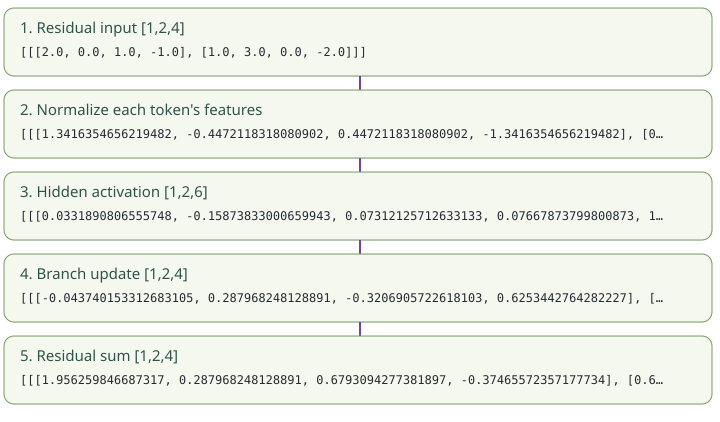

In [73]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

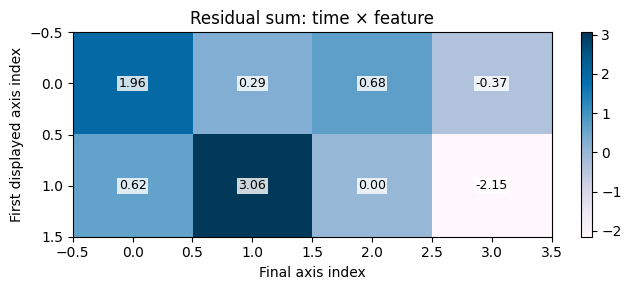

In [74]:
image = ((x+update)[0]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Residual sum: time × feature'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.12.3 · Read and run the code

Construct LayerNorm with the feature width to normalize. Passing a different tuple of normalized axes changes which entries contribute to each statistic.

Linear operates on the final axis while preserving the leading batch and time axes. The same parameters are applied to every token position.

Functional GELU and ReLU act element by element. GELU is deterministic; it is not a random dropout gate.

The residual expression adds the original tensor to the branch result. Check matching intended shapes instead of relying on accidental broadcasting.

Sequential can package the two linear layers and activation. Keeping the intermediate variables here makes their individual shapes inspectable.

### Change one thing

**Compare GELU with ReLU**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [75]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.tensor([[[2.,0.,1.,-1.],[1.,3.,0.,-2.]]])
show("Residual input [1,2,4]", x)
norm = nn.LayerNorm(4)
z = norm(x)
show("Normalize each token's features", z)
wide = nn.Linear(4, 6)
narrow = nn.Linear(6, 4)
hidden = wide(z)
activated = F.relu(hidden) if change else F.gelu(hidden)
show("Hidden activation [1,2,6]", activated)
update = narrow(activated)
show("Branch update [1,2,4]", update)
show("Residual sum [1,2,4]", x + update)

Residual input [1,2,4]: [[[2.0, 0.0, 1.0, -1.0], [1.0, 3.0, 0.0, -2.0]]]
  shape [1, 2, 4] · torch.float32 · cpu
Normalize each token's features: [[[1.3416354656219482, -0.4472118318080902, 0.4472118318080902, -1.3416354656219482], [0.27734971046447754, 1.3867484331130981, -0.27734965085983276, -1.3867484331130981]]]
  shape [1, 2, 4] · torch.float32 · cpu
Hidden activation [1,2,6]: [[[0.06319394707679749, 0.0, 0.1323145031929016, 0.13817280530929565, 1.4882413148880005, 0.019338905811309814], [0.0, 0.0, 0.6603927612304688, 0.0, 0.1478959321975708, 0.0]]]
  shape [1, 2, 6] · torch.float32 · cpu
Branch update [1,2,4]: [[[0.020684093236923218, 0.24581244587898254, -0.25400418043136597, 0.6117016077041626], [-0.22485506534576416, -0.027631843462586403, 0.0463280975818634, -0.16150955855846405]]]
  shape [1, 2, 4] · torch.float32 · cpu
Residual sum [1,2,4]: [[[2.020684003829956, 0.24581244587898254, 0.745995819568634, -0.3882983922958374], [0.7751449346542358, 2.9723682403564453, 0.0463280

### A useful distinction

The feed-forward branch changes features per token; its linear layers do not directly mix time positions.

### ✋ Your turn

Add a zero update to x=[2,0,1] and put the resulting list in answer.

In [76]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [2,0,1], 'The feed-forward branch changes features per token; its linear layers do not directly mix time positions.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [77]:
#@title Show a solution { display-mode: "form" }
x = torch.tensor([2.,0.,1.])
answer = (x + torch.zeros_like(x)).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [2,0,1], 'The feed-forward branch changes features per token; its linear layers do not directly mix time positions.'
    print("✓ right:", answer)

✓ right: [2.0, 0.0, 1.0]


### P1.12.4 · Find it in the model

The current transformer's branch widens twenty-eight features to fifty-six, applies GELU, and narrows back to twenty-eight. Its block uses normalization before each branch.

Phyll uses different widths and ReLU, plus dropout in its architecture. These differences must remain explicit when reading the larger model.

Dropout behaves differently in training and evaluation modes. LayerNorm continues to use the input's feature statistics in both modes.

This chapter establishes the API and shape contracts. The maths collection explains normalization, nonlinearity and residual addition in more numerical depth.

Next, interpret the final readout's scores and the targets used to measure their error.

```python
self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Linear(cfg.d_ff, cfg.d_model))
x = x + self.ff(self.ln2(x))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What width must the branch return for an intended residual add?

<details><summary>Check your explanation</summary>

The residual feature width. The feed-forward branch changes features per token; its linear layers do not directly mix time positions.

</details>

## P1.13 · Predictions, targets, and loss

Cross-entropy consumes raw logits and targets. Its average must count the valid supervised positions.

**Prerequisites:** Feed-forward blocks and residual paths

**Predict:** What should enter cross_entropy?

**Mental model:** A prediction contains one score for every candidate character. These raw scores are logits, and softmax converts them into probabilities for inspection or sampling.

### P1.13.1 · Understand the need

A prediction contains one score for every candidate character. These raw scores are logits, and softmax converts them into probabilities for inspection or sampling.

A target is the ID of the character that actually follows the context. Cross-entropy measures the negative log probability assigned to that target.

The library's cross-entropy operation accepts raw logits and performs its normalization stably. Applying softmax first changes the intended computation.

Padding or other intentionally ignored targets should contribute neither error nor an extra count to the average. Keep the denominator visible.

Accuracy asks whether the largest-score ID is correct. Loss also responds to the probability assigned to the correct ID, even when accuracy stays unchanged.

### P1.13.2 · Follow the values

The logits contain two examples, two time positions and three candidate IDs. The final axis is vocabulary, not time.

Softmax over that final axis creates a probability distribution for each position. These probabilities are displayed for understanding, not passed into cross-entropy.

Compute one loss per position. The ignored target produces zero in this unreduced output, while the three supervised positions each contribute their own loss.

Add the losses and divide by the valid count, three in the first experiment. Including the fourth target changes both the total and the count.

The predicted IDs match every supervised target in this illustration, so accuracy is exactly one. The positive loss still distinguishes these predictions from assigning probability one to every target.

In [78]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
logits = torch.tensor([[[2.,1.,0.],[1.,2.,0.]],[[0.,1.,2.],[3.,0.,0.]]])
targets = torch.tensor([[0,1],[2,0 if change else -100]])
show("Logits [B,T,V]", logits)
show("Probabilities over vocabulary", logits.softmax(-1))
losses = F.cross_entropy(logits.reshape(-1,3), targets.reshape(-1), ignore_index=-100, reduction="none").reshape(2,2)
show("Per-position losses; ignored position is zero", losses)
valid = targets != -100
mean = losses.sum()/valid.sum()
show("Valid count and mean", {"count": valid.sum().item(), "mean loss": mean.item()})
show("Correct IDs divided by valid count", ((logits.argmax(-1) == targets) & valid).sum().float()/valid.sum())
torch.testing.assert_close(mean, F.cross_entropy(logits.reshape(-1,3),targets.reshape(-1),ignore_index=-100))

Logits [B,T,V]: [[[2.0, 1.0, 0.0], [1.0, 2.0, 0.0]], [[0.0, 1.0, 2.0], [3.0, 0.0, 0.0]]]
  shape [2, 2, 3] · torch.float32 · cpu
Probabilities over vocabulary: [[[0.6652409434318542, 0.2447284758090973, 0.09003057330846786], [0.2447284758090973, 0.6652409434318542, 0.09003057330846786]], [[0.09003057330846786, 0.2447284758090973, 0.6652409434318542], [0.9094430208206177, 0.04527850076556206, 0.04527850076556206]]]
  shape [2, 2, 3] · torch.float32 · cpu
Per-position losses; ignored position is zero: [[0.40760594606399536, 0.40760594606399536], [0.40760594606399536, 0.0]]
  shape [2, 2] · torch.float32 · cpu
Valid count and mean: {"count": 3, "mean loss": 0.40760597586631775}
Correct IDs divided by valid count: 1.0
  shape [] · torch.float32 · cpu


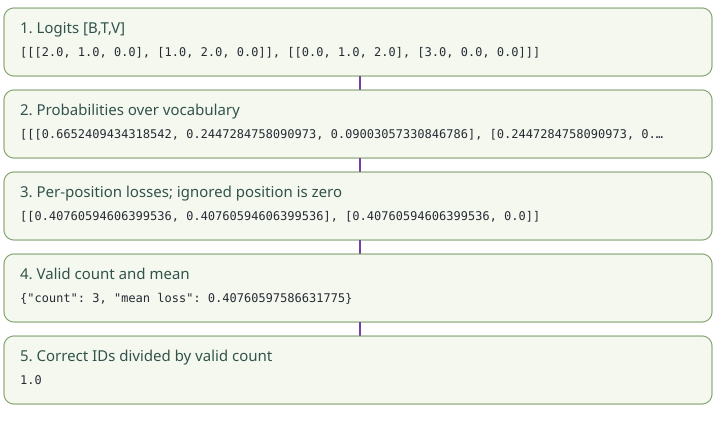

In [79]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

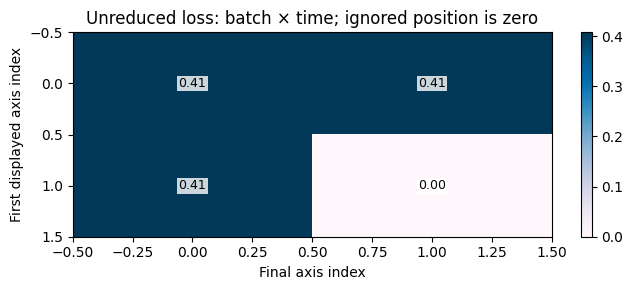

In [80]:
image = (losses).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Unreduced loss: batch × time; ignored position is zero'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.13.3 · Read and run the code

Reshape logits to a two-dimensional table of positions by candidates. Reshape targets to the matching one-dimensional sequence of target IDs.

Cross-entropy expects the candidate axis in its documented position. Flattening batch and time here makes that convention explicit.

Reduction none exposes individual losses. A Boolean validity mask supplies the denominator for the ordinary unweighted target-index mean used here.

Ignore index is a loss convention, not an instruction to remove a position from attention. The corresponding attention masking policy must be implemented separately.

An entirely ignored batch has no valid mean. Detect a zero valid count rather than reporting an invalid number as a meaningful training loss.

### Change one thing

**Include the fourth target**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [81]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
logits = torch.tensor([[[2.,1.,0.],[1.,2.,0.]],[[0.,1.,2.],[3.,0.,0.]]])
targets = torch.tensor([[0,1],[2,0 if change else -100]])
show("Logits [B,T,V]", logits)
show("Probabilities over vocabulary", logits.softmax(-1))
losses = F.cross_entropy(logits.reshape(-1,3), targets.reshape(-1), ignore_index=-100, reduction="none").reshape(2,2)
show("Per-position losses; ignored position is zero", losses)
valid = targets != -100
mean = losses.sum()/valid.sum()
show("Valid count and mean", {"count": valid.sum().item(), "mean loss": mean.item()})
show("Correct IDs divided by valid count", ((logits.argmax(-1) == targets) & valid).sum().float()/valid.sum())
torch.testing.assert_close(mean, F.cross_entropy(logits.reshape(-1,3),targets.reshape(-1),ignore_index=-100))

Logits [B,T,V]: [[[2.0, 1.0, 0.0], [1.0, 2.0, 0.0]], [[0.0, 1.0, 2.0], [3.0, 0.0, 0.0]]]
  shape [2, 2, 3] · torch.float32 · cpu
Probabilities over vocabulary: [[[0.6652409434318542, 0.2447284758090973, 0.09003057330846786], [0.2447284758090973, 0.6652409434318542, 0.09003057330846786]], [[0.09003057330846786, 0.2447284758090973, 0.6652409434318542], [0.9094430208206177, 0.04527850076556206, 0.04527850076556206]]]
  shape [2, 2, 3] · torch.float32 · cpu
Per-position losses; ignored position is zero: [[0.40760594606399536, 0.40760594606399536], [0.40760594606399536, 0.09492291510105133]]
  shape [2, 2] · torch.float32 · cpu
Valid count and mean: {"count": 4, "mean loss": 0.32943519949913025}
Correct IDs divided by valid count: 1.0
  shape [] · torch.float32 · cpu


### A useful distinction

ignore_index affects loss contributions. It does not automatically create an attention mask.

### ✋ Your turn

For losses [2,4,0] with only the first two positions valid, put the valid-position mean in answer.

In [82]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'ignore_index affects loss contributions. It does not automatically create an attention mask.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [83]:
#@title Show a solution { display-mode: "form" }
losses = torch.tensor([2.,4.,0.])
valid = torch.tensor([True,True,False])
answer = (losses.sum()/valid.sum()).item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'ignore_index affects loss contributions. It does not automatically create an attention mask.'
    print("✓ right:", answer)

✓ right: 3.0


### P1.13.4 · Find it in the model

The current model compares every input position's logits with its next-character target. Its fixed-length character windows do not need padded targets.

Phyll uses a padding ID that its loss ignores. The ID is specific to that tokenizer; zero is not universally padding in every model.

The library averages over valid target positions for the unweighted class-index case. Other loss weighting options can use a different normalization.

The training unit explains stable cross-entropy, dataset aggregation and the difference between fitting training data and improving validation performance.

Next, ask how this scalar loss supplies information to every parameter used in its computation.

```python
loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What should enter cross_entropy?

<details><summary>Check your explanation</summary>

Raw logits. ignore_index affects loss contributions. It does not automatically create an attention mask.

</details>

## P1.14 · Autograd follows the computation

Backward accumulates gradients for learned leaf tensors. Updating their values is a separate operation.

**Prerequisites:** Predictions, targets, and loss

**Predict:** Does backward update learned parameter values?

**Mental model:** A loss value measures the current prediction, but an optimizer also needs to know how parameter changes affect that loss locally. Gradients provide that information.

### P1.14.1 · Understand the need

A loss value measures the current prediction, but an optimizer also needs to know how parameter changes affect that loss locally. Gradients provide that information.

Autograd records differentiable operations while the forward calculation runs. The resulting graph describes dependencies between values.

Backward combines local derivatives along those dependencies and accumulates contributions at learned leaf parameters.

A gradient is a rate of change, not a new parameter value. The optimizer later chooses how to turn that information into an update.

Use one parameter and a small squared error first. This isolates the programming behavior before the same mechanism runs through an entire transformer.

### P1.14.2 · Follow the values

Start with a learned scalar weight of two and no stored gradient. The fixed input in the first experiment is three.

Multiplying the weight by the input predicts six. This intermediate depends on the weight, so autograd records that dependency.

The target is one. Squaring the difference gives a loss of twenty-five.

Backward accumulates a gradient of thirty at the weight. In this calculation the derivative is twice the prediction error times the input.

The weight is still two after backward. Changing the input to four changes the prediction, loss and gradient, while backward still leaves the parameter value unchanged.

In [84]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
w = torch.tensor(2., requires_grad=True)
x = torch.tensor(4. if change else 3.)
show("Leaf parameter before forward", {"w": w.item(), "grad": w.grad})
prediction = w*x
show("Prediction", prediction)
loss = (prediction-1).square()
show("Squared-error loss", loss)
loss.backward()
show("Gradient accumulated at w", w.grad)
show("Parameter after backward", w)

Leaf parameter before forward: {"w": 2.0, "grad": null}
Prediction: 6.0
  shape [] · torch.float32 · cpu
Squared-error loss: 25.0
  shape [] · torch.float32 · cpu
Gradient accumulated at w: 30.0
  shape [] · torch.float32 · cpu
Parameter after backward: 2.0
  shape [] · torch.float32 · cpu


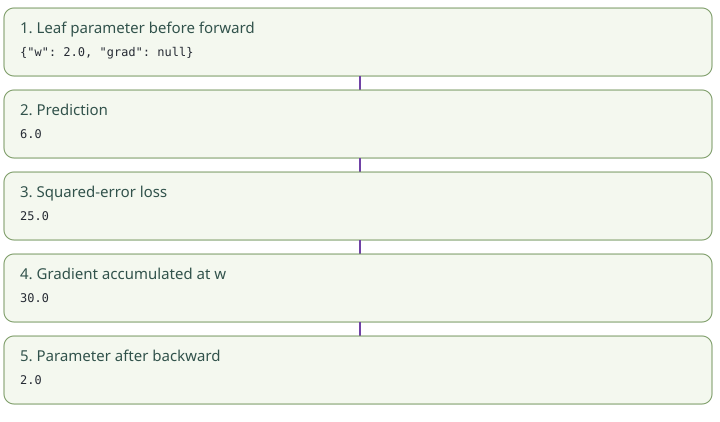

In [85]:
draw_trace()

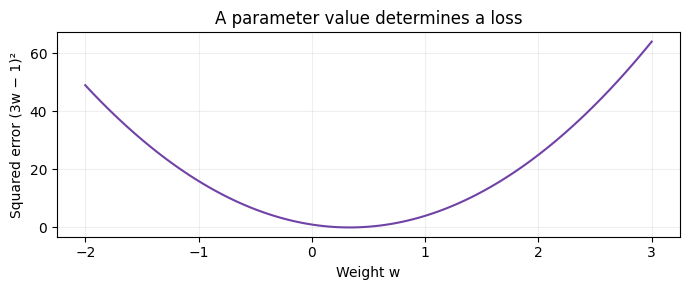

In [86]:
grid = torch.linspace(-2,3,120)
plt.figure(figsize=(7,3)); plt.plot(grid,(3*grid-1).square(),color="#7042a6")
plt.xlabel("Weight w"); plt.ylabel("Squared error (3w − 1)²"); plt.title("A parameter value determines a loss")
plt.grid(alpha=.2); plt.tight_layout(); plt.show()

### P1.14.3 · Read and run the code

Requires grad marks the leaf value whose gradient is needed. Operations using it create connected intermediate tensors while gradient recording is enabled.

The loss is scalar, so backward can begin from its implicit unit derivative. A non-scalar output requires an appropriate upstream gradient or a reduction.

Gradients normally accumulate in leaf tensors' grad fields. An intermediate's gradient is not automatically retained there for inspection.

Recomputing a forward graph and calling backward again adds another contribution unless gradients are cleared. The optimizer chapter will make clearing explicit.

Detach stops following a gradient connection but can share storage. Clone copies storage while remaining differentiable; detach followed by clone separates both concerns.

### Change one thing

**Increase the fixed input from 3 to 4**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [87]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
w = torch.tensor(2., requires_grad=True)
x = torch.tensor(4. if change else 3.)
show("Leaf parameter before forward", {"w": w.item(), "grad": w.grad})
prediction = w*x
show("Prediction", prediction)
loss = (prediction-1).square()
show("Squared-error loss", loss)
loss.backward()
show("Gradient accumulated at w", w.grad)
show("Parameter after backward", w)

Leaf parameter before forward: {"w": 2.0, "grad": null}
Prediction: 8.0
  shape [] · torch.float32 · cpu
Squared-error loss: 49.0
  shape [] · torch.float32 · cpu
Gradient accumulated at w: 56.0
  shape [] · torch.float32 · cpu
Parameter after backward: 2.0
  shape [] · torch.float32 · cpu


### A useful distinction

backward calculates and accumulates derivatives. It does not perform an optimizer update.

In [88]:
w = torch.tensor(2., requires_grad=True)
(w*3).backward(); first = w.grad.clone()
(w*3).backward(); torch.testing.assert_close(w.grad, first*2)
detached = w.detach(); copied = w.detach().clone()
assert not detached.requires_grad and not copied.requires_grad
assert detached.data_ptr() == w.data_ptr() and copied.data_ptr() != w.data_ptr()
print("Gradients accumulated; detach shared storage; detach plus clone copied it.")

Gradients accumulated; detach shared storage; detach plus clone copied it.


### ✋ Your turn

For w=2 with requires_grad=True, backpropagate through w.square() and put w.grad.item() in answer.

In [89]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'backward calculates and accumulates derivatives. It does not perform an optimizer update.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [90]:
#@title Show a solution { display-mode: "form" }
w = torch.tensor(2., requires_grad=True)
w.square().backward()
answer = w.grad.item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'backward calculates and accumulates derivatives. It does not perform an optimizer update.'
    print("✓ right:", answer)

✓ right: 4.0


### P1.14.4 · Find it in the model

The model's scalar cross-entropy depends on projections, embeddings, normalization parameters and the readout. Autograd follows those actual tensor operations.

Shared token and readout weights receive contributions from both uses. There is one parameter with the sum of the relevant derivative contributions.

Integer input IDs name lookup entries; they are not continuous parameters to differentiate as magnitudes. The embedding weights receive gradients instead.

Converting a tensor to a Python value and rebuilding a new tensor can break the intended graph. Inspect grad function and requires grad when diagnosing a missing derivative.

Next, use the accumulated gradients in an optimizer step and verify exactly when values change.

```python
optimizer.zero_grad(set_to_none=True)
logits, loss = model(x, y)
loss.backward()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does backward update learned parameter values?

<details><summary>Check your explanation</summary>

No; it accumulates gradients. backward calculates and accumulates derivatives. It does not perform an optimizer update.

</details>

# Section 4 · Learn and generate

- P1.15 · Perform one training step
- P1.16 · Evaluation and repeatable experiments
- P1.17 · Generate one token at a time
- P1.18 · Read, run, save, and restore

## P1.15 · Perform one training step

Clear old gradients, calculate loss, backpropagate, then let the optimizer update the parameters.

**Prerequisites:** Autograd follows the computation

**Predict:** Which operation changes parameter values?

**Mental model:** The training step has several distinct jobs. Clearing gradients, calculating derivatives and changing parameters are separate operations with separate observable effects.

### P1.15.1 · Understand the need

The training step has several distinct jobs. Clearing gradients, calculating derivatives and changing parameters are separate operations with separate observable effects.

An optimizer receives the parameters it is allowed to update. A tensor missing from that collection can participate in a calculation without being changed by this optimizer.

A simple gradient-descent update subtracts learning rate times gradient. This gives a transparent first example before using the course's AdamW optimizer.

A larger step is not automatically a better step. A local derivative describes nearby change and does not promise improvement for any chosen distance.

Inspect the parameter before and after every stage. That makes the training loop a sequence you can explain rather than a recipe you repeat from memory.

### P1.15.2 · Follow the values

The parameter starts at two and the first learning rate is one tenth. The optimizer has a reference to this parameter.

Clear its old gradient. Its value remains two, and its gradient field is None with this clearing option.

Forward and backward give loss twenty-five and gradient thirty. The parameter still has its original value.

The optimizer subtracts one tenth times thirty. The new weight is minus one, demonstrating the first actual parameter change.

Recomputing the loss gives sixteen. Switch to learning rate one half and the step overshoots severely, showing why a valid gradient does not guarantee a good update at every scale.

In [91]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
w = nn.Parameter(torch.tensor(2.))
lr = .5 if change else .1
optimizer = torch.optim.SGD([w], lr=lr)
show("Parameter and learning rate", {"w": w.item(), "lr": lr})
optimizer.zero_grad(set_to_none=True)
show("After clearing gradients", {"w": w.item(), "grad": w.grad})
loss = (3*w-1).square()
loss.backward()
show("After backward", {"loss": loss.item(), "gradient": w.grad.item(), "w": w.item()})
optimizer.step()
show("After optimizer step", w)
show("Recomputed loss", (3*w-1).square())

Parameter and learning rate: {"w": 2.0, "lr": 0.1}
After clearing gradients: {"w": 2.0, "grad": null}
After backward: {"loss": 25.0, "gradient": 30.0, "w": 2.0}
After optimizer step: -1.0
  shape [] · torch.float32 · cpu
Recomputed loss: 16.0
  shape [] · torch.float32 · cpu


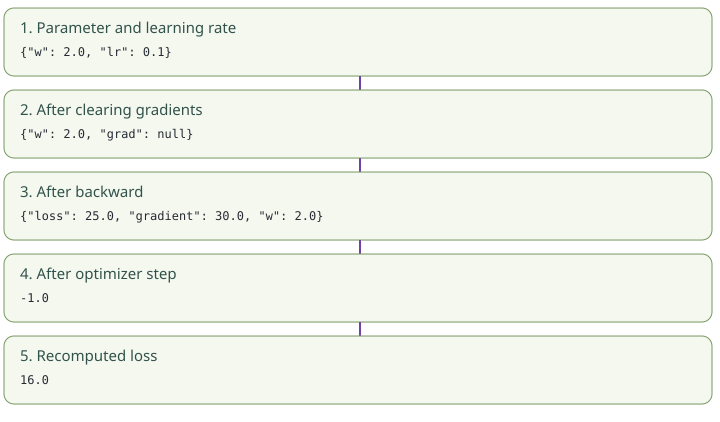

In [92]:
draw_trace()

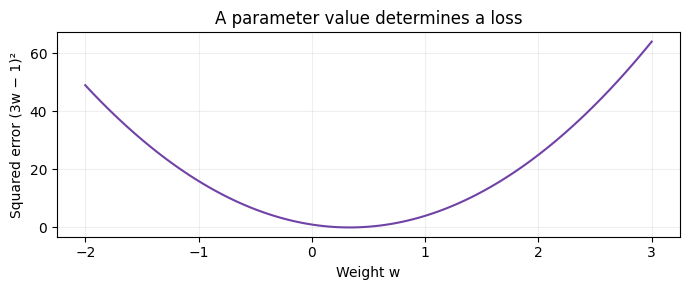

In [93]:
grid = torch.linspace(-2,3,120)
plt.figure(figsize=(7,3)); plt.plot(grid,(3*grid-1).square(),color="#7042a6")
plt.xlabel("Weight w"); plt.ylabel("Squared error (3w − 1)²"); plt.title("A parameter value determines a loss")
plt.grid(alpha=.2); plt.tight_layout(); plt.show()

### P1.15.3 · Read and run the code

Create a Parameter, then give that object to the optimizer. Replacing it with a new unrelated tensor later would not automatically replace the optimizer's reference.

Zero grad clears accumulated derivative information; it does not reset weights or optimizer moving averages. Set to none can leave a gradient absent until backward produces it.

Compute a fresh loss from the current parameters, then call backward. Avoid accidentally reusing a freed graph from a previous iteration.

Step applies the optimizer rule using the available gradients. Recompute the loss afterward if you want to measure the new parameter state.

AdamW follows the same call order but has a different update rule and internal state. The training unit develops its moving averages and weight decay.

### Change one thing

**Increase the learning rate to 0.5**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [94]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
w = nn.Parameter(torch.tensor(2.))
lr = .5 if change else .1
optimizer = torch.optim.SGD([w], lr=lr)
show("Parameter and learning rate", {"w": w.item(), "lr": lr})
optimizer.zero_grad(set_to_none=True)
show("After clearing gradients", {"w": w.item(), "grad": w.grad})
loss = (3*w-1).square()
loss.backward()
show("After backward", {"loss": loss.item(), "gradient": w.grad.item(), "w": w.item()})
optimizer.step()
show("After optimizer step", w)
show("Recomputed loss", (3*w-1).square())

Parameter and learning rate: {"w": 2.0, "lr": 0.5}
After clearing gradients: {"w": 2.0, "grad": null}
After backward: {"loss": 25.0, "gradient": 30.0, "w": 2.0}
After optimizer step: -13.0
  shape [] · torch.float32 · cpu
Recomputed loss: 1600.0
  shape [] · torch.float32 · cpu


### A useful distinction

zero_grad does not reset parameters, and a large learning rate can increase the loss.

### ✋ Your turn

Starting at w=2, take an SGD step with gradient 4 and learning rate 0.1; put the new scalar in answer.

In [95]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(answer - 1.6) < 1e-6, 'zero_grad does not reset parameters, and a large learning rate can increase the loss.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [96]:
#@title Show a solution { display-mode: "form" }
answer = 2.0 - 0.1*4.0

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(answer - 1.6) < 1e-6, 'zero_grad does not reset parameters, and a large learning rate can increase the loss.'
    print("✓ right:", answer)

✓ right: 1.6


### P1.15.4 · Find it in the model

The actual character-model training loop uses AdamW. The same clear, forward, backward, step sequence appears around every sampled batch.

Each step updates the currently registered parameters from that batch's gradient estimate. A step is not necessarily an epoch over the dataset.

Stochastic batches and optimizer state mean that recorded loss need not fall at every individual step. Validation measures a separate question about held-out data.

Saving only weights preserves the learned prediction function, while resuming the same optimization also requires the relevant optimizer and run state.

Next, separate training-mode behavior from gradient recording and make small experiments repeatable.

```python
optimizer.zero_grad(set_to_none=True)
_, loss = model(x, y)
loss.backward()
optimizer.step()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which operation changes parameter values?

<details><summary>Check your explanation</summary>

optimizer.step(). zero_grad does not reset parameters, and a large learning rate can increase the loss.

</details>

## P1.16 · Evaluation and repeatable experiments

Module mode controls behaviors such as dropout. Grad mode independently controls autograd recording.

**Prerequisites:** Perform one training step

**Predict:** Does eval disable autograd?

**Mental model:** Two switches often appear together when evaluating a model, but they control different behavior. Module mode and gradient recording should be understood independently.

### P1.16.1 · Understand the need

Two switches often appear together when evaluating a model, but they control different behavior. Module mode and gradient recording should be understood independently.

Train and eval change modules that define mode-dependent behavior. Dropout is a concrete example: its training behavior randomly removes and rescales entries.

No grad stops recording operations for differentiation in a region. It does not automatically put modules into evaluation mode.

Evaluation mode does not stop autograd either. A model can produce differentiable evaluation-mode outputs when that is what the program needs.

Seeded randomness makes small experiments easier to compare. Reproducibility still depends on the operation, runtime and device, not on a seed alone.

### P1.16.2 · Follow the values

The input consists of eight ones. The first experiment uses dropout probability one half, meaning each training entry is independently eligible to be dropped.

In training mode, some entries become zero and retained entries are rescaled. A particular short sample need not contain exactly half zeros.

In evaluation mode, dropout returns the original values without dropping them. This mode change is visible even with the same input.

The evaluation result still requires gradients because the input does. Eval has not disabled recording.

Inside no grad, a new calculation produces doubled values without a recorded gradient dependency. Change the dropout probability and compare which stages are affected.

In [97]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
drop = nn.Dropout(.25 if change else .5)
x = torch.ones(8, requires_grad=True)
show("Input and dropout probability", {"x": x.detach().tolist(), "p": drop.p})
drop.train()
training = drop(x)
show("Training-mode output", training)
drop.eval()
evaluation = drop(x)
show("Evaluation-mode output", evaluation)
show("Eval still records gradients", evaluation.requires_grad)
with torch.no_grad():
    quiet = drop(x*2)
show("Independent no-grad region", {"values": quiet.tolist(), "requires_grad": quiet.requires_grad})

Input and dropout probability: {"x": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], "p": 0.5}
Training-mode output: [2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0]
  shape [8] · torch.float32 · cpu
Evaluation-mode output: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  shape [8] · torch.float32 · cpu
Eval still records gradients: true
Independent no-grad region: {"values": [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0], "requires_grad": false}


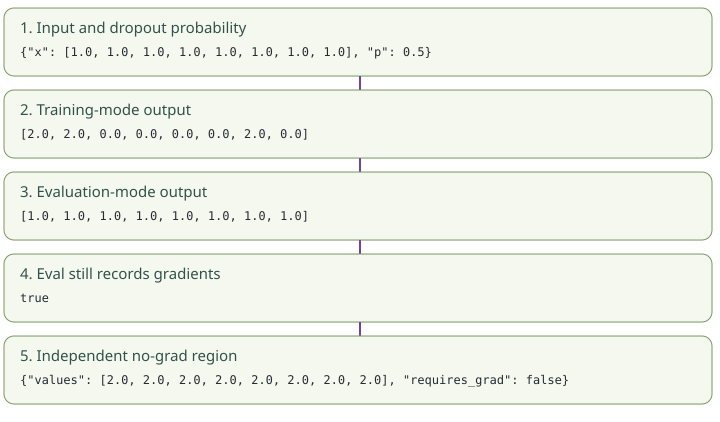

In [98]:
draw_trace()

### P1.16.3 · Read and run the code

Call train before training-mode behavior and eval before evaluation-mode behavior. The call recursively updates registered submodules.

Use no grad around calculations that do not need a backward graph. Inference mode is a stronger option with additional restrictions on later autograd use.

Seed a generator when you want an isolated stream of random draws, and record the runtime used for repeatable examples. A global seed affects several later random operations.

Keep tensors and model parameters on compatible devices. When comparing floating-point outputs, use tolerances appropriate to their precision and numerical scale.

Restore training mode after validation if more optimization follows. Context managers restore their own grad mode, while eval is a module state change you must manage.

### Change one thing

**Use dropout probability 0.25**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [99]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
drop = nn.Dropout(.25 if change else .5)
x = torch.ones(8, requires_grad=True)
show("Input and dropout probability", {"x": x.detach().tolist(), "p": drop.p})
drop.train()
training = drop(x)
show("Training-mode output", training)
drop.eval()
evaluation = drop(x)
show("Evaluation-mode output", evaluation)
show("Eval still records gradients", evaluation.requires_grad)
with torch.no_grad():
    quiet = drop(x*2)
show("Independent no-grad region", {"values": quiet.tolist(), "requires_grad": quiet.requires_grad})

Input and dropout probability: {"x": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], "p": 0.25}
Training-mode output: [1.3333333730697632, 1.3333333730697632, 0.0, 1.3333333730697632, 0.0, 0.0, 1.3333333730697632, 1.3333333730697632]
  shape [8] · torch.float32 · cpu
Evaluation-mode output: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  shape [8] · torch.float32 · cpu
Eval still records gradients: true
Independent no-grad region: {"values": [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0], "requires_grad": false}


### A useful distinction

eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.

In [100]:
g1 = torch.Generator().manual_seed(17)
g2 = torch.Generator().manual_seed(17)
assert torch.equal(torch.rand(5,generator=g1), torch.rand(5,generator=g2))
with torch.inference_mode():
    output = nn.Linear(2,2)(torch.ones(1,2))
assert not output.requires_grad
print("Seeds reproduced these CPU draws; inference output needs no backward graph.")

Seeds reproduced these CPU draws; inference output needs no backward graph.


### ✋ Your turn

Put whether nn.Dropout(0.5).eval()(torch.ones(2, requires_grad=True)) requires gradients in answer.

In [101]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer is True, 'eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [102]:
#@title Show a solution { display-mode: "form" }
answer = nn.Dropout(0.5).eval()(torch.ones(2, requires_grad=True)).requires_grad

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer is True, 'eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.'
    print("✓ right:", answer)

✓ right: True


### P1.16.4 · Find it in the model

Our tiny model has no dropout layer, but Phyll does. Eval therefore changes Phyll's dropout behavior even when a tiny-model demonstration appears unchanged.

LayerNorm uses current-input feature statistics in both modes. Do not transfer BatchNorm's running-statistics behavior to LayerNorm.

The generation method disables gradients because generation does not backpropagate through sampled text. Evaluation mode is still a separate architectural concern.

The training unit uses fixed evaluation batches and recorded seeds to make comparisons meaningful. Identical seeds do not promise bitwise equality across every platform.

Next, use evaluation outputs to choose and append one new token at a time.

```python
model.eval()
with torch.no_grad():
    logits, loss = model(x, targets)
model.train()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does eval disable autograd?

<details><summary>Check your explanation</summary>

No; module mode and grad mode are independent. eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.

</details>

## P1.17 · Generate one token at a time

Choose from the last position’s distribution, append the selected ID, then calculate the next prediction from the updated context.

**Prerequisites:** Evaluation and repeatable experiments

**Predict:** Which time position supplies the next-token distribution?

**Mental model:** The model predicts a distribution over the next token. Generation turns that one-step prediction into a sequence by repeating prediction and selection.

### P1.17.1 · Understand the need

The model predicts a distribution over the next token. Generation turns that one-step prediction into a sequence by repeating prediction and selection.

Only the last available time position supplies the next-token distribution. Earlier positions describe earlier next-token questions.

Greedy decoding selects a largest-score candidate. Sampling instead draws an ID according to the predicted probabilities, so different draws can produce different continuations.

Temperature rescales the logits before softmax. A positive higher temperature typically spreads probability more evenly; it does not add learned knowledge.

Append the selected ID, keep the permitted recent context, and run the model again. A recorded sample must identify how its selection was performed.

### P1.17.2 · Follow the values

Begin with one sequence containing IDs zero and one. The example supplies fixed illustrative logits to isolate selection from model computation.

The candidate scores are two, one and zero. These are three alternatives at the final time position, not scores for three time steps.

At temperature one, softmax gives the largest score the largest probability. Temperature two makes the distribution less concentrated.

Multinomial draws one ID using a seeded generator. The sampled tensor keeps a batch axis and a singleton selection axis.

Concatenate the selected ID along time. The full sequence grows, while a context crop can keep only the recent positions used for the next model call.

In [103]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
ids = torch.tensor([[0,1]])
show("Current context", ids)
logits = torch.tensor([[2.,1.,0.]])
show("Illustrative last-position logits", logits)
temperature = 2. if change else 1.
probabilities = (logits/temperature).softmax(-1)
show("Candidate probabilities", probabilities)
next_id = torch.multinomial(probabilities, 1, generator=torch.Generator().manual_seed(7))
show("Sampled next ID [B,1]", next_id)
extended = torch.cat([ids,next_id], dim=1)
show("Append; then crop if needed", {"full sequence": extended.tolist(), "last two positions": extended[:, -2:].tolist()})

Current context: [[0, 1]]
  shape [1, 2] · torch.int64 · cpu
Illustrative last-position logits: [[2.0, 1.0, 0.0]]
  shape [1, 3] · torch.float32 · cpu
Candidate probabilities: [[0.6652409434318542, 0.2447284758090973, 0.09003057330846786]]
  shape [1, 3] · torch.float32 · cpu
Sampled next ID [B,1]: [[0]]
  shape [1, 1] · torch.int64 · cpu
Append; then crop if needed: {"full sequence": [[0, 1, 0]], "last two positions": [[1, 0]]}


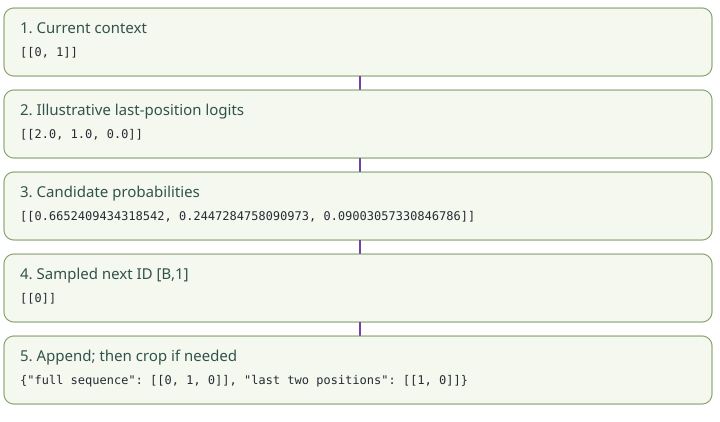

In [104]:
draw_trace()

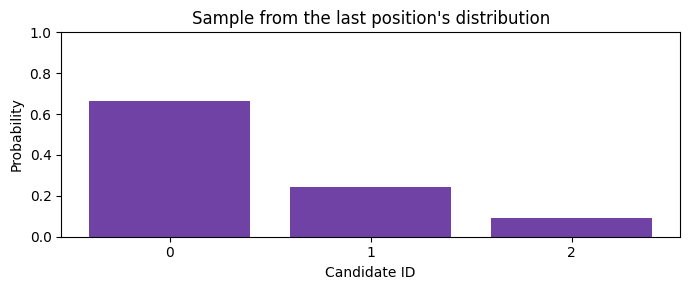

In [105]:
plt.figure(figsize=(7,3)); plt.bar(range(3),probabilities[0].numpy(),color="#7042a6")
plt.xticks(range(3)); plt.xlabel("Candidate ID"); plt.ylabel("Probability"); plt.ylim(0,1)
plt.title("Sample from the last position's distribution"); plt.tight_layout(); plt.show()

### P1.17.3 · Read and run the code

Select logits at the final time position before sampling. Divide by a strictly positive temperature, then normalize over the vocabulary axis.

Argmax implements a greedy selection. Multinomial takes nonnegative weights, here normalized probabilities, and returns integer candidate IDs.

Preserve shape batch by one for the sampled IDs so cat can extend the time axis of the input batch.

Top-k restricts candidates by replacing excluded logits before softmax. More advanced nucleus filtering is developed in the later decoding lesson.

Stop according to the generation contract: a requested length, an end-token policy, or both. Batched stopping requires tracking each example rather than treating many IDs as one scalar.

### Change one thing

**Raise temperature to 2**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [106]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
ids = torch.tensor([[0,1]])
show("Current context", ids)
logits = torch.tensor([[2.,1.,0.]])
show("Illustrative last-position logits", logits)
temperature = 2. if change else 1.
probabilities = (logits/temperature).softmax(-1)
show("Candidate probabilities", probabilities)
next_id = torch.multinomial(probabilities, 1, generator=torch.Generator().manual_seed(7))
show("Sampled next ID [B,1]", next_id)
extended = torch.cat([ids,next_id], dim=1)
show("Append; then crop if needed", {"full sequence": extended.tolist(), "last two positions": extended[:, -2:].tolist()})

Current context: [[0, 1]]
  shape [1, 2] · torch.int64 · cpu
Illustrative last-position logits: [[2.0, 1.0, 0.0]]
  shape [1, 3] · torch.float32 · cpu
Candidate probabilities: [[0.5064803957939148, 0.30719590187072754, 0.18632373213768005]]
  shape [1, 3] · torch.float32 · cpu
Sampled next ID [B,1]: [[0]]
  shape [1, 1] · torch.int64 · cpu
Append; then crop if needed: {"full sequence": [[0, 1, 0]], "last two positions": [[1, 0]]}


### A useful distinction

Temperature changes a distribution produced by the current weights. It does not train the model.

In [107]:
z = torch.tensor([[2.,1.,0.]])
threshold = torch.topk(z,2,dim=-1).values[:, -1:]
p = z.masked_fill(z < threshold, -float("inf")).softmax(-1)
assert p[0,2].item() == 0
assert torch.allclose(p.sum(-1), torch.ones(1))
print("Top-k threshold filtering:", p.tolist())

Top-k threshold filtering: [[0.7310585975646973, 0.2689414322376251, 0.0]]


### ✋ Your turn

Append ID 2 to the sequence [[0,1]] along its time axis and put the nested list in answer.

In [108]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[0,1,2]], 'Temperature changes a distribution produced by the current weights. It does not train the model.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [109]:
#@title Show a solution { display-mode: "form" }
answer = torch.cat([torch.tensor([[0,1]]), torch.tensor([[2]])], dim=1).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[0,1,2]], 'Temperature changes a distribution produced by the current weights. It does not train the model.'
    print("✓ right:", answer)

✓ right: [[0, 1, 2]]


### P1.17.4 · Find it in the model

The current generator repeatedly crops to its maximum context, calls the model, selects the final logits, samples and appends. Every iteration computes a new distribution.

Learned absolute position indices are recreated for the supplied window. Context cropping and position conventions should match the trained architecture.

Phyll also has an end-token convention and optional top-k filtering. Its tokenizer determines how selected IDs decode to text pieces.

One update of an untrained model does not establish coherent language. The training unit's recorded checkpoints show how generation changes over meaningful training progress.

Next, run the complete tiny model and preserve its learned state through a save-and-load round trip.

```python
logits, _ = self(idx[:, -self.cfg.block_size:])
probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
nxt = torch.multinomial(probs, 1, generator=generator)
idx = torch.cat([idx, nxt], dim=1)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which time position supplies the next-token distribution?

<details><summary>Check your explanation</summary>

The final available position. Temperature changes a distribution produced by the current weights. It does not train the model.

</details>

## P1.18 · Read, run, save, and restore

Configuration constructs the architecture; a state dictionary supplies its stored tensors. Verify the loaded model with the same input.

**Prerequisites:** Generate one token at a time

**Predict:** What is required to load a state dictionary for inference?

**Mental model:** The final notebook combines the tensor skills in the course's actual tiny architecture. The model is initialized afresh so the experiment cannot alter the recorded checkpoint.

<a id="pytorch-practice"></a>

### P1.18.1 · Understand the need

The final notebook combines the tensor skills in the course's actual tiny architecture. The model is initialized afresh so the experiment cannot alter the recorded checkpoint.

Configuration describes which layers and shapes to construct. A state dictionary supplies the tensors that fit that architecture.

A saved prediction function should reproduce its outputs when loaded into a matching model and evaluated on the same input.

Resuming a training run asks for more than weights: the optimizer and relevant run state matter as well. Distinguish those two saving goals.

This capstone proves that you can operate and inspect the model. It does not claim that a single training step produces meaningful language.

### Included reference model

The current Unit 1 architecture. A descriptive alias names it `TinyTransformer`. This creates fresh parameters; it does not load or change a recorded checkpoint.

In [110]:
#@title Reference architecture (expand to inspect) { display-mode: "form" }
"""Our tiny transformer: 9,417 learned numbers that predict the next character of Shakespeare.

It reads up to 32 characters of text and gives a probability to each of the 65 characters that could come next. Writing is
that prediction in a loop: pick a character, append it, slide the 32-character window, and predict again. (The class is
called Prompter for the course's file names; learners meet it as "our tiny transformer".)

The architecture is the "10k" configuration of maxpolaczuk/tiny-character-transformer (a 1-block, 2-head character GPT on Tiny
Shakespeare). The code here is written fresh for the course (that repository has no licence, so none of its code or weights
are copied): every line is one the course teaches.

    characters ─► token table (65 × 28) + position table (32 × 28)        lookup:      what, and where
               ─► one block: LayerNorm ─► 2-head causal attention ─► +    look back:   which earlier letters matter
                             LayerNorm ─► feed-forward 28 → 56 → 28 ─► +  think:       transform each row on its own
               ─► final LayerNorm ─► readout with the token table again   score all 65 characters
               ─► softmax                                                  probabilities for the next character

Parameters: token table 1,820 · positions 896 · block 6,580 (two LayerNorms 112, q|k|v 2,436, attention out 812,
feed-forward 1,624 + 1,596) · final LayerNorm 56 · readout bias 65 = 9,417.
"""

import math
from dataclasses import asdict, dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass(frozen=True)
class Config:
    vocab_size: int = 65    # every distinct character in Tiny Shakespeare
    block_size: int = 32    # how many characters the model can read at once (its context)
    d_model: int = 28       # how many numbers describe one character in one place (a row)
    n_head: int = 2         # attention heads, each looking with 28 / 2 = 14 numbers
    d_ff: int = 56          # the feed-forward network's hidden width (2 × d_model)
    n_layer: int = 1        # transformer blocks

    def to_dict(self):
        return asdict(self)


class Tokenizer:
    """One id per character, in sorted order: '\\n' is 0, ' ' is 1, … 'z' is 64."""

    def __init__(self, text: str):
        self.chars = sorted(set(text))
        self.stoi = {c: i for i, c in enumerate(self.chars)}

    def encode(self, s: str) -> list[int]:
        return [self.stoi[c] for c in s]

    def decode(self, ids) -> str:
        return "".join(self.chars[int(i)] for i in ids)


class CausalSelfAttention(nn.Module):
    """Each row asks a question (q), every earlier row offers a label (k) and a message (v). A row reads the messages of the
    rows whose labels match its question best, never a row to its right."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.n_head, self.head_dim = cfg.n_head, cfg.d_model // cfg.n_head
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)     # q, k and v for both heads in one matrix
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)        # mix the heads' results back into one row
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        self.register_buffer("mask", mask.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, keep=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in (q, k, v))
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)          # how well each question matches each label
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))   # no peeking at the future
        att = F.softmax(att, dim=-1)                                          # shares that add up to 1
        if keep is not None:
            keep["attn"] = att.detach()
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)            # each row: a weighted mix of messages
        return self.proj(y)


class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Linear(cfg.d_ff, cfg.d_model))

    def forward(self, x, keep=None):
        x = x + self.attn(self.ln1(x), keep)    # look back, and add what was found to the row
        x = x + self.ff(self.ln2(x))            # think about each row on its own, and add that too
        return x


class Prompter(nn.Module):
    def __init__(self, cfg: Config = Config()):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)    # one learned row per character
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)    # one learned row per place 0 … 31
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head_bias = nn.Parameter(torch.zeros(cfg.vocab_size))  # the readout reuses tok_emb (tied); only its bias is new
        self.apply(self._init)

    @staticmethod
    def _init(m):
        # small random numbers (σ = 0.02), so the untrained model's guesses are nearly even: its first loss is about
        # ln 65 = 4.17, the loss of a uniform guess over 65 characters
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None, keep=None):
        T = idx.size(1)
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))   # what + where
        for b in self.blocks:
            x = b(x, keep)
        x = self.ln_f(x)
        logits = x @ self.tok_emb.weight.T + self.head_bias                         # a score for every character
        loss = None if targets is None else F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, n, temperature=1.0, generator=None):
        for _ in range(n):
            logits, _ = self(idx[:, -self.cfg.block_size:])
            probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1, generator=generator)
            idx = torch.cat([idx, nxt], dim=1)
        return idx


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

TinyTransformer = Prompter

### P1.18.2 · Follow the values

Construct the current architecture and count its unique learned elements. The count is 9,417, with the configuration displayed beside it.

Pass a batch of one four-token sequence and its shifted targets. The logits have shape one by four by sixty-five, and the loss is scalar.

Backpropagate and inspect the token-table gradient. Its shape matches the table's sixty-five entries of twenty-eight features.

Let AdamW perform one update, then compare the embedding against a copied pre-update snapshot. The comparison confirms that optimization changed stored values.

Save and reload the state into a matching fresh model. The same input now produces identical CPU outputs in this experiment, with maximum absolute difference zero.

In [111]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
import io
torch.manual_seed(11 if change else 7)
model = TinyTransformer()
show("Current architecture", {"parameters": sum(p.numel() for p in model.parameters()), "config": model.cfg.to_dict()})
ids = torch.tensor([[1,2,3,4]])
targets = torch.tensor([[2,3,4,5]])
logits, loss = model(ids, targets)
show("Forward contract", {"logits shape": list(logits.shape), "loss": loss.item()})
before = model.tok_emb.weight.detach().clone()
optimizer = torch.optim.AdamW(model.parameters(), lr=.001)
optimizer.zero_grad(set_to_none=True)
loss.backward()
show("Embedding gradient shape", model.tok_emb.weight.grad.shape)
optimizer.step()
show("Embedding changed", not torch.equal(before, model.tok_emb.weight))
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
buffer.seek(0)
restored = TinyTransformer(model.cfg)
restored.load_state_dict(torch.load(buffer, map_location="cpu", weights_only=True))
model.eval(); restored.eval()
with torch.no_grad():
    expected, _ = model(ids)
    actual, _ = restored(ids)
show("Reload maximum absolute difference", (actual-expected).abs().max())
torch.testing.assert_close(actual, expected)

Current architecture: {"parameters": 9417, "config": {"vocab_size": 65, "block_size": 32, "d_model": 28, "n_head": 2, "d_ff": 56, "n_layer": 1}}
Forward contract: {"logits shape": [1, 4, 65], "loss": 4.246893405914307}


Embedding gradient shape: [65, 28]
Embedding changed: true
Reload maximum absolute difference: 0.0
  shape [] · torch.float32 · cpu


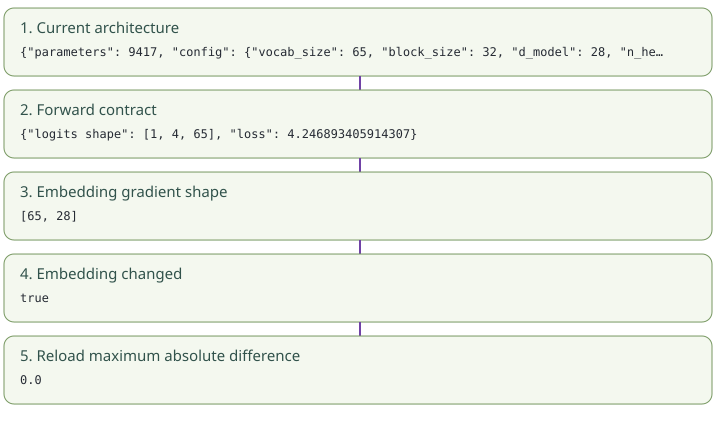

In [112]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

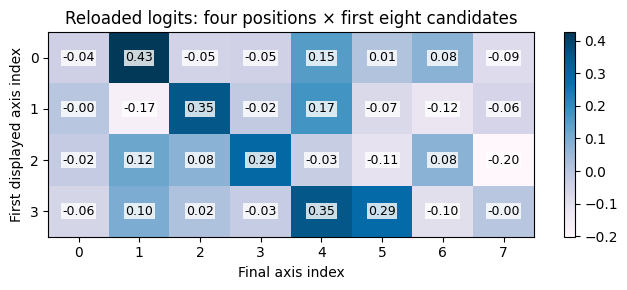

In [113]:
image = (actual[0,:,:8]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Reloaded logits: four positions × first eight candidates'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.18.3 · Read and run the code

The notebook embeds the current reference model, keeping the experiment independent of a repository clone. Its source is checked against the course model during generation.

Use an explicit seed before construction and keep the input and target tensors visible. The learned values here are newly initialized, not the trained Unit One checkpoint.

Clone the detached pre-update weight when preserving a comparison snapshot. Merely saving a second reference would not protect the earlier values.

Save the state dictionary and load it into the matching architecture with weights only and an explicit CPU mapping. A vocabulary mapping must be preserved alongside weights for decoded text.

Compare outputs after loading, and inspect missing or unexpected state keys instead of hiding an architecture mismatch. The training unit develops complete resumable checkpoints.

### Change one thing

**Initialize with seed 11**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [114]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
import io
torch.manual_seed(11 if change else 7)
model = TinyTransformer()
show("Current architecture", {"parameters": sum(p.numel() for p in model.parameters()), "config": model.cfg.to_dict()})
ids = torch.tensor([[1,2,3,4]])
targets = torch.tensor([[2,3,4,5]])
logits, loss = model(ids, targets)
show("Forward contract", {"logits shape": list(logits.shape), "loss": loss.item()})
before = model.tok_emb.weight.detach().clone()
optimizer = torch.optim.AdamW(model.parameters(), lr=.001)
optimizer.zero_grad(set_to_none=True)
loss.backward()
show("Embedding gradient shape", model.tok_emb.weight.grad.shape)
optimizer.step()
show("Embedding changed", not torch.equal(before, model.tok_emb.weight))
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
buffer.seek(0)
restored = TinyTransformer(model.cfg)
restored.load_state_dict(torch.load(buffer, map_location="cpu", weights_only=True))
model.eval(); restored.eval()
with torch.no_grad():
    expected, _ = model(ids)
    actual, _ = restored(ids)
show("Reload maximum absolute difference", (actual-expected).abs().max())
torch.testing.assert_close(actual, expected)

Current architecture: {"parameters": 9417, "config": {"vocab_size": 65, "block_size": 32, "d_model": 28, "n_head": 2, "d_ff": 56, "n_layer": 1}}
Forward contract: {"logits shape": [1, 4, 65], "loss": 4.165988445281982}


Embedding gradient shape: [65, 28]
Embedding changed: true
Reload maximum absolute difference: 0.0
  shape [] · torch.float32 · cpu


### A useful distinction

Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.

In [115]:
with torch.no_grad():
    generated = restored.generate(ids, 4, generator=torch.Generator().manual_seed(7))
assert generated.shape == (1,8)
print("Generated IDs from a model after one update, not a trained-language claim:", generated.tolist())
try:
    restored(torch.tensor([[65]]))
except IndexError:
    print("The embedding rejects an ID outside the vocabulary.")

Generated IDs from a model after one update, not a trained-language claim: [[1, 2, 3, 4, 16, 58, 2, 5]]
The embedding rejects an ID outside the vocabulary.


### ✋ Your turn

For the current TinyTransformer, put its unique parameter count in answer.

In [116]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 9417, 'Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [117]:
#@title Show a solution { display-mode: "form" }
answer = sum(p.numel() for p in TinyTransformer().parameters())

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 9417, 'Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.'
    print("✓ right:", answer)

✓ right: 9417


### P1.18.4 · Find it in the model

You have now followed IDs through lookups, normalized branches, attention, feed-forward transformations and a tied vocabulary readout. Every intermediate has a shape contract.

You can distinguish logits, loss, gradients and updated parameters. They are related stages rather than interchangeable measurements of learning.

The maths collection derives the calculations you have executed. Unit One reconnects them into a complete model, and Unit Two develops the training workflow and its evidence.

Phyll scales and modifies parts of the architecture. Its larger tensors, padding rules, dropout and tokenizer require explicit comparisons, while these programming foundations transfer.

Return to a chapter when a new line of model code feels opaque. Predict the values and axes first, run a small case, and check the result.

```python
model = TinyTransformer(config)
model.load_state_dict(saved_weights)
model.eval()
with torch.no_grad():
    logits, _ = model(ids)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What is required to load a state dictionary for inference?

<details><summary>Check your explanation</summary>

A matching architecture and configuration. Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.

</details>